# Investment Supply-Chain & Nature Dependency Analysis

Combines IO-based supply-chain footprint (Sankey / waterfall / scenario comparison) with a three-layer nature dependency overlay (ENCORE materiality · WWF Risk Filter · supply-chain sector sensitivity). Edit the **PARAMETERS** cell then **Run All**.

In [1]:
# ══════════════════════════════════════════════════════════════════
# PARAMETERS  ← edit here, then Run All
# ══════════════════════════════════════════════════════════════════
CAPEX_USD   = 100_000_000
COUNTRY     = "DE"
SECTOR      = "Rail_Dev"       # Health_Social | Energy | Rail_Dev | Rail_Op
DATABASE    = "exiobase"
SCENARIO    = "SSP2-4.5"       # None for baseline
FOCUS_YEAR  = 2030
COMPARE_SSPS = True
from pathlib import Path
RESULTS_DIR = Path("results")
REPO_ROOT   = Path(".").resolve().parent
TOP_N       = 5


In [2]:
# ══════════════════════════════════════════════════════════════════
# IMPORTS, COLOUR PALETTES, DEP CONSTANTS
# ══════════════════════════════════════════════════════════════════
import sys
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

sys.path.insert(0, str(REPO_ROOT / "tvp_dbio"))
sys.path.insert(0, str(REPO_ROOT / "tvp_dependency"))

from tvp_io_lib import (
    tier0_impact, tier1_impact, tier_impact,
    ISO2_TO_REGION, SECTOR_ALLOC,
)
from dependency_profiler.encore_materiality import (
    MATERIALITY_MATRIX, RATING_SCALE, ECOSYSTEM_SERVICES,
    get_materiality_profile,
)
from dependency_profiler.wwf_risk_filter import (
    score_project, REGIONAL_BASELINES, HIGH_RISK_THRESHOLD,
)

# ── Colour palettes ────────────────────────────────────────────────────────
TIER_NODE = {"t0": "#4e79a7", "t1": "#f28e2b", "t2": "#59a14f", "t3": "#b07aa1"}
TIER_LINK = {
    "t0": "rgba(78,121,167,0.35)", "t1": "rgba(242,142,43,0.35)",
    "t2": "rgba(89,161,79,0.35)",  "t3": "rgba(176,122,161,0.35)",
}
INTER  = {"t0": "#aec7e8", "t1": "#ffbb78", "t2": "#98df8a", "t3": "#c5b0d5"}
STRESSORS = [
    ("GHG_tCO2e",      "GHG",        "tCO2e",   "#d62728", "[-]"),
    ("Employment_FTE", "Employment", "FTE",      "#2ca02c", "[+]"),
    ("Water_1000m3",   "Water",      "000 m3",   "#1f77b4", "[-]"),
]
ALL_SSPS   = ["SSP1-1.9","SSP2-4.5","SSP3-7.0","SSP4-6.0","SSP5-8.5"]
SSP_COLORS = {
    "SSP1-1.9":"#1a9641","SSP2-4.5":"#a6d96a",
    "SSP3-7.0":"#fdae61","SSP4-6.0":"#f46d43","SSP5-8.5":"#d73027",
}
INTENSITY_CSV = REPO_ROOT / "tvp_scenario" / "osemosys" / "results" / "tvpdbio_intensity_factors.csv"
# ── Methodology constants: imported from assess.py (single source of truth) ──
# Ensures the notebook uses exactly the same sector mappings, ecosystem-service
# groupings and supply-chain sensitivity profiles as the portfolio-level assess.py.
#
#   PROJECT_SECTOR_TO_ENCORE  — maps portfolio sector codes to ENCORE sector keys
#   STRESSOR_ECOSYSTEM_MAP    — ecosystem services that mediate each stressor
#   STRESSOR_WWF_COL          — WWF sub-score column relevant to each stressor
#   STRESSOR_SC_DEP_KEY       — SC_SECTOR_DEP_PROFILE sub-key per stressor
#   SC_SECTOR_DEP_PROFILE     — per-supplying-sector nature dependency scores (1–5)
#                               Source: ENCORE analogues + IPBES 2019 Global
#                               Assessment sector biodiversity pressure typology
#   DEP_NEUTRAL = 3.0         — midpoint of 1–5 scale → dep_factor == 1.0 here
sys.path.insert(0, str(REPO_ROOT / "project_assessment"))
from assess import (
    PROJECT_SECTOR_TO_ENCORE,
    STRESSOR_ECOSYSTEM_MAP,
    STRESSOR_WWF_COL,
    STRESSOR_SC_DEP_KEY,
    SC_SECTOR_DEP_PROFILE,
    DEP_NEUTRAL,
)
SC_SECTOR_DEP = SC_SECTOR_DEP_PROFILE   # local alias used in dep_factor()
STRESSOR_SC_KEY = STRESSOR_SC_DEP_KEY   # local alias used in dep_factor()
DEP_THRESHOLD = HIGH_RISK_THRESHOLD     # 3.4  from wwf_risk_filter

# ── Country / region resolution ───────────────────────────────────────────
COUNTRY_NAMES = {
    "germany":"DE","france":"FR","uk":"GB","united kingdom":"GB",
    "spain":"ES","italy":"IT","netherlands":"NL","poland":"PL",
    "sweden":"SE","norway":"NO","switzerland":"CH","turkey":"TR",
    "brazil":"BR","mexico":"MX","argentina":"AR","colombia":"CO",
    "chile":"CL","peru":"PE","south africa":"ZA","nigeria":"NG",
    "kenya":"KE","ethiopia":"ET","ghana":"GH","egypt":"EG","morocco":"MA",
    "china":"CN","india":"IN","japan":"JP","south korea":"KR",
    "indonesia":"ID","thailand":"TH","vietnam":"VN",
    "russia":"RU","united states":"US","usa":"US","canada":"CA","australia":"AU",
}

def resolve(country):
    u = country.strip().upper()
    if u in ISO2_TO_REGION: return ISO2_TO_REGION[u]
    rm = {r.upper(): r for r in ("Europe","LATAM","Africa","Asia","Global")}
    if u in rm: return rm[u]
    iso2 = COUNTRY_NAMES.get(country.strip().lower())
    return ISO2_TO_REGION.get(iso2, "Global") if iso2 else "Global"

def fmt_capex(v):
    return f"${v/1e9:.2f}B" if v >= 1e9 else f"${v/1e6:.1f}M" if v >= 1e6 else f"${v:,.0f}"

REGION        = resolve(COUNTRY)
ENCORE_SECTOR = PROJECT_SECTOR_TO_ENCORE.get(SECTOR, "rail_transport")
DEP_REGION    = REGION.lower() if REGION.lower() in REGIONAL_BASELINES else "europe"
print(f"Country: {COUNTRY} -> Region: {REGION}  |  ENCORE: {ENCORE_SECTOR}")

Country: DE -> Region: Europe  |  ENCORE: rail_transport


In [3]:
# ══════════════════════════════════════════════════════════════════
# IO ANALYSIS  (Leontief tiers 0-10)
# ══════════════════════════════════════════════════════════════════
print("[1/4] Tier 0 ...", end=" ", flush=True)
t0_res = tier0_impact(CAPEX_USD, SECTOR, REGION, DATABASE)
print(f"GHG {t0_res['GHG_tCO2e']:,.0f}")

print("[2/4] Tier 1 bilateral ...", end=" ", flush=True)
t1_res = tier1_impact(CAPEX_USD, SECTOR, REGION, DATABASE)
print(f"GHG {t1_res['GHG_tCO2e']:,.0f}")

print("[3/4] Tier 2 ...", end=" ", flush=True)
t2_raw = tier_impact(CAPEX_USD, SECTOR, REGION, DATABASE, tier_from=2, tier_to=2)
print(f"{len(t2_raw)} rows")

print("[4/4] Tier 3-10 ...", end=" ", flush=True)
t3_raw = tier_impact(CAPEX_USD, SECTOR, REGION, DATABASE, tier_from=3, tier_to=10)
print(f"{len(t3_raw)} rows")

PID = f"{SECTOR}_{REGION}_{fmt_capex(CAPEX_USD)}"

def _t0_df():
    rows = [{"project_id":PID,"supplying_sector":sec,
             **{k:v for k,v in vals.items() if k!="spend_M$"}}
            for sec,vals in t0_res["impact_by_sector"].items()]
    return pd.DataFrame(rows)

def _t1_df():
    rows = [{"project_id":PID,"supplying_sector":sec,"sourcing_region":reg,
             **{k:v for k,v in rv.items() if k not in ("share","spend_M$")}}
            for sec,regions in t1_res["tier1_by_sector"].items()
            for reg,rv in regions.items()]
    return pd.DataFrame(rows)

t0 = _t0_df(); t1 = _t1_df()
t2 = t2_raw.copy(); t2["project_id"] = PID
t3 = t3_raw.copy(); t3["project_id"] = PID

COLS_SC = ["GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
print(f"\n{'Stressor':<22} {'T0':>10} {'T1':>10} {'T2':>10} {'T3-10':>10} {'Total':>12}")
print("-"*70)
for c in COLS_SC:
    v = [df[c].sum() if c in df.columns else 0 for df in [t0,t1,t2,t3]]
    print(f"  {c:<20} {v[0]:>10,.0f} {v[1]:>10,.0f} {v[2]:>10,.0f} {v[3]:>10,.0f} {sum(v):>12,.0f}")

# ── Aliases so sankey sections (S1-S7) work alongside dep sections (S8-S14)
t2_df_raw = t2_raw
t3_df_raw = t3_raw
COLS      = COLS_SC


[1/4] Tier 0 ... 

GHG 18,830
[2/4] Tier 1 bilateral ... 

GHG 10,994
[3/4] Tier 2 ... 

40 rows
[4/4] Tier 3-10 ... 

320 rows

Stressor                       T0         T1         T2      T3-10        Total
----------------------------------------------------------------------
  GHG_tCO2e                18,830     10,994      5,113      4,462       39,400
  Employment_FTE              674        378        181        160        1,393
  Water_1000m3                111         80         40         35          267
  ValueAdded_M$                52         28         13         12          105


In [4]:
# ══════════════════════════════════════════════════════════════════
# SCENARIO FACTORS + DEPENDENCY SETUP
# ══════════════════════════════════════════════════════════════════
def _load_factors(region, scenario, year):
    if not INTENSITY_CSV.exists() or scenario is None: return None
    df  = pd.read_csv(INTENSITY_CSV)
    row = df[(df["region"]==region)&(df["scenario"]==scenario)&(df["year"]==float(year))]
    if row.empty: return None
    r  = row.iloc[0]
    rs = float(r.get("renewable_share", 0.5))
    return {
        "GHG_tCO2e":      float(r["adj_ratio_ghg"]),
        "Employment_FTE": float(r["adj_ratio_employment"]),
        "Water_1000m3":   float(rs * 0.15 + (1 - rs) * 1.0),
        "ValueAdded_M$":  float(r["adj_ratio_employment"]),
    }

def _apply(val, col, factors):
    return val * factors[col] if (factors and col in factors) else val

FACTORS     = _load_factors(REGION, SCENARIO, FOCUS_YEAR)
ALL_FACTORS = {s: _load_factors(REGION, s, FOCUS_YEAR) for s in ALL_SSPS}
sc_label    = f"{SCENARIO} {FOCUS_YEAR}" if SCENARIO and FACTORS else "Baseline"
# ── ENCORE dependency scores via get_materiality_profile() ────────────────
# Source: encore_materiality.MATERIALITY_MATRIX
#   ENCORE v2024 methodology (UNEP-WCMC / UNEP FI / Global Canopy).
#   Mean dependency score over the ecosystem services in STRESSOR_ECOSYSTEM_MAP.
_enc_profile_main = get_materiality_profile(ENCORE_SECTOR)
ENCORE_DEP = {}
print(f"ENCORE dep scores  [{ENCORE_SECTOR}]  "
      "source: encore_materiality.MATERIALITY_MATRIX")
for stressor, svcs in STRESSOR_ECOSYSTEM_MAP.items():
    _dep_scores = [_enc_profile_main.ratings.get(svc, {}).get("dependency_score", 0)
                   for svc in svcs]
    ENCORE_DEP[stressor] = sum(_dep_scores) / max(len(_dep_scores), 1)
    print(f"  {stressor:<22} = {ENCORE_DEP[stressor]:.2f}  "
          f"({', '.join(svcs)})")

# ── WWF WRF/BRF scores via score_project() ────────────────────────────────
# Source: wwf_risk_filter.REGIONAL_BASELINES (basin-level WRF/BRF indicators)
#   x wwf_risk_filter.SECTOR_SENSITIVITY multipliers for ENCORE_SECTOR.
#   No hardcoded fallback numbers. All values computed live from the module.
print(f"\nWWF scores  source: wwf_risk_filter.score_project()  sector={ENCORE_SECTOR}")
WWF_BY_REGION = {}
for _dep_reg in REGIONAL_BASELINES:
    _res = score_project(f"_dyn_{_dep_reg}", _dep_reg, ENCORE_SECTOR)
    WWF_BY_REGION[_dep_reg] = {
        "wrf_physical":       _res.wrf.physical,
        "wrf_regulatory":     _res.wrf.regulatory,
        "wrf_reputational":   _res.wrf.reputational,
        "wrf_composite":      _res.wrf.composite,
        "brf_species_threat": _res.brf.species_threat,
        "brf_ecosystem":      _res.brf.ecosystem_intactness,
        "brf_protected_areas":_res.brf.protected_areas,
        "brf_composite":      _res.brf.composite,
    }
    _flag = "  [HIGH RISK]" if _res.overall_high_risk else ""
    print(f"  {_dep_reg:<8}  WRF={_res.wrf.composite:.3f}  "
          f"BRF={_res.brf.composite:.3f}{_flag}")

def get_wwf(region_str):
    key = (region_str or "").lower()
    return WWF_BY_REGION.get(key, WWF_BY_REGION.get("europe", {}))


# ── dep_factor: three-component formula from assess.py ────────────────────
def dep_factor(stressor, sourcing_region, supplying_sector):
    enc  = ENCORE_DEP.get(stressor, DEP_NEUTRAL)
    wwf  = get_wwf(sourcing_region).get(STRESSOR_WWF_COL[stressor], DEP_NEUTRAL)
    sc   = SC_SECTOR_DEP.get(supplying_sector, {}).get(STRESSOR_SC_KEY[stressor], DEP_NEUTRAL)
    base = (enc/DEP_NEUTRAL + wwf/DEP_NEUTRAL) / 2.0
    return (base + sc/DEP_NEUTRAL) / 2.0

# ── Tier-level weighted mean dep_factor ───────────────────────────────────
TIER_DEP = {}
for tier_key, df, region_col in [
    ("t0", t0, None),
    ("t1", t1, "sourcing_region"),
    ("t2", t2, None),
    ("t3", t3, None),
]:
    TIER_DEP[tier_key] = {}
    for st in COLS_SC:
        if st not in df.columns or df.empty:
            TIER_DEP[tier_key][st] = 1.0
            continue
        weights = np.abs(df[st].values) + 1e-9
        factors = [
            dep_factor(st,
                       row.get(region_col, REGION) if region_col else REGION,
                       row["supplying_sector"])
            for _, row in df.iterrows()
        ]
        TIER_DEP[tier_key][st] = float(np.average(factors, weights=weights))

# ── Three-layer summary per tier ──────────────────────────────────────────
def _raw(df, c):  return df[c].sum() if c in df.columns else 0.0
def _adj(df, c):  return _apply(_raw(df, c), c, FACTORS)
def _dep(raw_adj, tk, c): return raw_adj * TIER_DEP[tk][c]

TIER_DEFS   = [("t0","Tier 0  Direct",t0),
               ("t1","Tier 1  Bilateral",t1),
               ("t2","Tier 2  Upstream",t2),
               ("t3","Tier 3-10  Deep",t3)]

SUMMARY = {}
for tk,_,df in TIER_DEFS:
    SUMMARY[tk] = {
        "raw": {c: _raw(df,c) for c in COLS_SC},
        "adj": {c: _adj(df,c) for c in COLS_SC},
        "dep": {c: _dep(_adj(df,c), tk, c) for c in COLS_SC},
    }
GRAND = {
    layer: {c: sum(SUMMARY[tk][layer][c] for tk,*_ in TIER_DEFS)
            for c in COLS_SC}
    for layer in ["raw","adj","dep"]
}

print(f"Scenario: {sc_label}")
if FACTORS:
    for k,v in FACTORS.items(): print(f"  {k:<22} x{v:.4f}")
print("\nDependency factors (tier x stressor):")
for tk,label,_ in TIER_DEFS:
    vals = "  ".join(f"{c.split('_')[0]}={TIER_DEP[tk][c]:.3f}" for c in COLS_SC)
    print(f"  {label:<22} {vals}")


ENCORE dep scores  [rail_transport]  source: encore_materiality.MATERIALITY_MATRIX
  GHG_tCO2e              = 1.50  (climate_regulation, mediation_of_gaseous_waste)
  Employment_FTE         = 3.33  (terrestrial_ecosystem_use, soil_quality, erosion_control)
  Water_1000m3           = 2.67  (water_supply, water_flow_regulation, freshwater_ecosystem_use)
  ValueAdded_M$          = 2.67  (water_supply, climate_regulation, terrestrial_ecosystem_use)

WWF scores  source: wwf_risk_filter.score_project()  sector=rail_transport
  africa    WRF=3.610  BRF=3.774  [HIGH RISK]
  asia      WRF=3.966  BRF=4.181  [HIGH RISK]
  europe    WRF=3.378  BRF=3.133
  latam     WRF=3.567  BRF=4.268  [HIGH RISK]


Scenario: SSP2-4.5 2030
  GHG_tCO2e              x0.6700
  Employment_FTE         x1.1128
  Water_1000m3           x0.5053
  ValueAdded_M$          x1.1128

Dependency factors (tier x stressor):
  Tier 0  Direct         GHG=0.936  Employment=1.181  Water=1.166  ValueAdded=1.097
  Tier 1  Bilateral      GHG=0.971  Employment=1.183  Water=1.263  ValueAdded=1.147
  Tier 2  Upstream       GHG=0.961  Employment=1.179  Water=1.233  ValueAdded=1.145
  Tier 3-10  Deep        GHG=0.962  Employment=1.179  Water=1.234  ValueAdded=1.145


In [5]:
# ══════════════════════════════════════════════════════════════════
# LEGEND
# ══════════════════════════════════════════════════════════════════
def _badge(col, label, extra=""):
    return (f"<span style='background:{col};color:white;"
            f"padding:2px 7px;border-radius:3px'>{label}</span>{extra}")

display(HTML(f"""
<div style='font-family:Arial;font-size:12px;padding:9px 14px;
            background:#f5f5f5;border-radius:5px;margin:8px 0'>
<b>Investment:</b> {fmt_capex(CAPEX_USD)} &nbsp;·&nbsp;
<b>Country:</b> {COUNTRY} ({REGION}) &nbsp;·&nbsp;
<b>Sector:</b> {SECTOR} &nbsp;·&nbsp;
<b>ENCORE:</b> {ENCORE_SECTOR} &nbsp;·&nbsp;
<b>Layer:</b> {sc_label}
<br><br>
{_badge('#4e79a7','Tier 0','&nbsp;')}
{_badge('#f28e2b','Tier 1','&nbsp;')}
{_badge('#59a14f','Tier 2','&nbsp;')}
{_badge('#b07aa1','Tier 3-10','&emsp;')}
<b>dep_factor neutral=1.0</b> &nbsp;
<span style='color:#d62728'>&gt;1.0 amplifies</span> /
<span style='color:#2ca02c'>&lt;1.0 dampens</span> nature-related risk
</div>
"""))


In [6]:
# ══════════════════════════════════════════════════════════════════
# PART A — SUPPLY-CHAIN FOOTPRINT  (Sections 1–7)
# ══════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════
# SECTION 1 — MAIN SANKEY  (identical structure to project_sankey)
# ══════════════════════════════════════════════════════════════════
def _top_n_other(s: pd.Series, n=TOP_N) -> pd.Series:
    s = s[s > 0]
    if len(s) <= n: return s
    top  = s.nlargest(n)
    rest = s[~s.index.isin(top.index)].sum()
    return pd.concat([top, pd.Series({"Other": rest})]) if rest > 0 else top

def _sankey_data(col):
    nodes, nc = [], []
    src, tgt, val, lc = [], [], [], []

    def node(label, color):
        if label not in nodes: nodes.append(label); nc.append(color)
        return nodes.index(label)

    def flows(tier_idx, breakdown, tk, prefix):
        for name, v in breakdown.items():
            mid = node(f"{prefix}{name}", INTER[tk])
            c   = TIER_LINK[tk]
            src.extend([tier_idx, mid]); tgt.extend([mid, term_idx])
            val.extend([v, v]);          lc.extend([c, c])

    meta  = next(m for m in STRESSORS if m[0] == col)
    _, sname, sunit, s_col, ssign = meta

    t0v = _apply(t0[col].sum(), col, FACTORS)
    t1v = _apply(t1[col].sum(), col, FACTORS)
    t2v = _apply(t2[col].sum() if col in t2.columns else 0, col, FACTORS)
    t3v = _apply(t3[col].sum() if col in t3.columns else 0, col, FACTORS)
    grand = t0v + t1v + t2v + t3v

    i0 = node("Tier 0\nDirect CAPEX",      TIER_NODE["t0"])
    i1 = node("Tier 1\nBilateral Sourcing", TIER_NODE["t1"])
    i2 = node("Tier 2\nSecond Upstream",    TIER_NODE["t2"])
    i3 = node("Tier 3–10\nDeep Upstream",   TIER_NODE["t3"])
    term_idx = node(f"{sname}\n{grand:,.0f} {sunit}", s_col)

    # T0: sector
    flows(i0, _top_n_other(
        t0.groupby("supplying_sector")[col].sum()
          .apply(lambda v: _apply(v, col, FACTORS))), "t0", "T0 ")

    # T1: sourcing region (bilateral)
    flows(i1, _top_n_other(
        t1.groupby("sourcing_region")[col].sum()
          .apply(lambda v: _apply(v, col, FACTORS))), "t1", "T1 ")

    # T2: sector
    if t2v > 0:
        flows(i2, _top_n_other(
            t2.groupby("supplying_sector")[col].sum()
              .apply(lambda v: _apply(v, col, FACTORS))), "t2", "T2 ")

    # T3-10: sector
    if t3v > 0:
        flows(i3, _top_n_other(
            t3.groupby("supplying_sector")[col].sum()
              .apply(lambda v: _apply(v, col, FACTORS))), "t3", "T3+ ")

    return dict(nodes=nodes, nc=nc, src=src, tgt=tgt, val=val, lc=lc,
                grand=grand, sname=sname, sunit=sunit, s_col=s_col, ssign=ssign)


n, gap = len(STRESSORS), 0.03
w = (1.0 - gap * (n - 1)) / n
fig = go.Figure()

for i, (col, *_) in enumerate(STRESSORS):
    d  = _sankey_data(col)
    x0, x1 = i*(w+gap), i*(w+gap)+w
    fig.add_trace(go.Sankey(
        domain=dict(x=[x0, x1], y=[0, 0.90]),
        arrangement="snap",
        node=dict(label=d["nodes"], color=d["nc"], pad=14, thickness=18,
                  line=dict(color="white", width=0.4)),
        link=dict(source=d["src"], target=d["tgt"],
                  value=d["val"],  color=d["lc"]),
    ))
    fig.add_annotation(
        x=(x0+x1)/2, y=1.0, xref="paper", yref="paper",
        text=(f"<b>{d['ssign']} {d['sname']}</b><br>"
              f"<span style='font-size:11px;color:{d['s_col']}'>"
              f"{d['grand']:,.0f} {d['sunit']}</span>"),
        showarrow=False, font=dict(size=13), align="center")

sc_note = f" — {sc_label}"
fig.update_layout(
    title=dict(
        text=(f"<b>Supply-Chain Sankey{sc_note}</b>"
              f"<br><span style='font-size:12px;color:#555'>"
              f"{fmt_capex(CAPEX_USD)} · {COUNTRY} ({REGION}) · {SECTOR}</span>"),
        x=0.01, xanchor="left", font=dict(size=15)),
    height=590, margin=dict(l=20, r=20, t=105, b=20),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10))
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))


In [7]:
# ══════════════════════════════════════════════════════════════════
# SECTION 2 — TIER CONTRIBUTION  (stacked bar, all 4 stressors)
# ══════════════════════════════════════════════════════════════════
tier_map = {
    "Tier 0  Direct":   t0,
    "Tier 1  Bilateral": t1,
    "Tier 2  Upstream": t2,
    "Tier 3-10  Deep":  t3,
}
tier_colors = ["#4e79a7", "#f28e2b", "#59a14f", "#b07aa1"]

stressor_display = [
    ("GHG_tCO2e",      "GHG tCO₂e [−]",    "#d62728"),
    ("Employment_FTE", "Employment FTE [+]", "#2ca02c"),
    ("Water_1000m3",   "Water 000 m³ [−]",   "#1f77b4"),
    ("ValueAdded_M$",  "VA M USD [+]",        "#9467bd"),
]

fig2 = go.Figure()
for tname, df_t in tier_map.items():
    tc = tier_colors[list(tier_map.keys()).index(tname)]
    vals = []
    for col, *_ in stressor_display:
        v = df_t[col].sum() if col in df_t.columns else 0.0
        vals.append(_apply(v, col, FACTORS))
    fig2.add_trace(go.Bar(
        name=tname,
        x=[d[1] for d in stressor_display],
        y=vals,
        marker_color=tc,
        text=[f"{v:,.0f}" if v > 1 else "" for v in vals],
        textposition="inside",
        insidetextanchor="middle",
        textfont=dict(color="white", size=9),
    ))

# Deep upstream % annotation
for ci, (col, label, _) in enumerate(stressor_display):
    tot = sum((_apply(df_t[col].sum() if col in df_t.columns else 0, col, FACTORS))
              for df_t in tier_map.values())
    deep = _apply(t3[col].sum() if col in t3.columns else 0, col, FACTORS)
    if tot > 0:
        fig2.add_annotation(
            x=label, y=tot * 1.04,
            text=f"Deep {deep/tot*100:.0f}%",
            showarrow=False, font=dict(size=9, color="#b07aa1"), yanchor="bottom")

fig2.update_layout(
    title=f"<b>Tier Contribution by Stressor</b> — {sc_label}",
    barmode="stack",
    yaxis_title="Stressor value (native units)",
    height=400,
    legend=dict(orientation="h", y=1.05),
    margin=dict(l=80, r=60, t=80, b=60),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig2.to_html(full_html=False, include_plotlyjs="cdn")))


In [8]:
# ══════════════════════════════════════════════════════════════════
# SECTION 3 — TIER 1 BILATERAL SOURCING
# 3a: stacked bar — sourcing region by supplying sector
# 3b: heatmap — GHG by supplying sector × sourcing region
# ══════════════════════════════════════════════════════════════════

# 3a: stacked bars (region stacks per sector)
regions  = sorted(t1["sourcing_region"].unique())
sectors  = sorted(t1["supplying_sector"].unique())
reg_col  = ["#4e79a7","#f28e2b","#59a14f","#b07aa1","#e15759"]

fig3a = go.Figure()
for ri, reg in enumerate(regions):
    sub = t1[t1["sourcing_region"] == reg]
    ghg_by_sec = sub.groupby("supplying_sector")["GHG_tCO2e"].sum().reindex(sectors, fill_value=0)
    ghg_adj    = ghg_by_sec.apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
    fig3a.add_trace(go.Bar(
        name=reg,
        x=sectors,
        y=ghg_adj.values,
        marker_color=reg_col[ri % len(reg_col)],
        text=[f"{v:,.0f}" if v > 100 else "" for v in ghg_adj],
        textposition="inside", insidetextanchor="middle",
        textfont=dict(color="white", size=8),
    ))

fig3a.update_layout(
    title=f"<b>Tier 1 GHG — Sourcing Region by Sector</b> · {sc_label}",
    barmode="stack",
    xaxis_tickangle=-30,
    yaxis_title="GHG tCO₂e",
    height=380, legend=dict(orientation="h", y=1.05),
    margin=dict(l=70, r=40, t=80, b=90),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig3a.to_html(full_html=False, include_plotlyjs="cdn")))

# 3b: heatmap — sector × region
piv = (t1.groupby(["supplying_sector", "sourcing_region"])["GHG_tCO2e"]
         .sum()
         .apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
         .unstack(fill_value=0))

fig3b = go.Figure(go.Heatmap(
    z=piv.values,
    x=piv.columns.tolist(),
    y=piv.index.tolist(),
    colorscale="YlOrRd",
    text=[[f"{v:,.0f}" for v in row] for row in piv.values],
    texttemplate="%{text}",
    textfont=dict(size=9),
    colorbar=dict(title="GHG tCO₂e"),
))
fig3b.update_layout(
    title=f"<b>Tier 1 GHG Heatmap</b> — supplying sector × sourcing region · {sc_label}",
    xaxis_title="Sourcing Region", yaxis_title="Supplying Sector",
    height=360, margin=dict(l=160, r=60, t=70, b=60),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig3b.to_html(full_html=False, include_plotlyjs="cdn")))


In [9]:
# ══════════════════════════════════════════════════════════════════
# SECTION 4 — DEEP UPSTREAM SECTOR BREAKDOWN  (Tier 3-10)
# Shows where the 'invisible' deep supply-chain burden comes from
# ══════════════════════════════════════════════════════════════════
fig4 = go.Figure()

for col, label, col_color in [
    ("GHG_tCO2e",      "GHG tCO₂e",  "#d62728"),
    ("Employment_FTE", "Jobs FTE",    "#2ca02c"),
    ("Water_1000m3",   "Water 000m³", "#1f77b4"),
]:
    if col not in t3.columns: continue
    by_sec = (t3.groupby("supplying_sector")[col].sum()
                .apply(lambda v: _apply(v, col, FACTORS))
                .sort_values(ascending=True))
    fig4.add_trace(go.Bar(
        name=label,
        y=by_sec.index,
        x=by_sec.values,
        orientation="h",
        marker_color=col_color,
        opacity=0.8,
        text=[f"{v:,.1f}" for v in by_sec],
        textposition="outside",
        textfont=dict(size=9),
    ))

fig4.update_layout(
    title=f"<b>Tier 3-10 Deep Upstream</b> — sector breakdown · {sc_label}",
    barmode="group",
    xaxis_title="Stressor (native units — axes differ)",
    height=400,
    legend=dict(orientation="h", y=1.05),
    margin=dict(l=160, r=80, t=80, b=50),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig4.to_html(full_html=False, include_plotlyjs="cdn")))


In [10]:
# ══════════════════════════════════════════════════════════════════
# SECTION 5 — TIER WATERFALL  (GHG cumulative)
# Shows the running total as each tier is added
# ══════════════════════════════════════════════════════════════════
tier_ghg = [
    ("Tier 0",    _apply(t0["GHG_tCO2e"].sum(), "GHG_tCO2e", FACTORS), "#4e79a7"),
    ("Tier 1",    _apply(t1["GHG_tCO2e"].sum(), "GHG_tCO2e", FACTORS), "#f28e2b"),
    ("Tier 2",    _apply(t2["GHG_tCO2e"].sum() if "GHG_tCO2e" in t2.columns else 0, "GHG_tCO2e", FACTORS), "#59a14f"),
    ("Tier 3-10", _apply(t3["GHG_tCO2e"].sum() if "GHG_tCO2e" in t3.columns else 0, "GHG_tCO2e", FACTORS), "#b07aa1"),
]

labels   = [t[0] for t in tier_ghg]
values   = [t[1] for t in tier_ghg]
colors   = [t[2] for t in tier_ghg]
base     = [0] + list(np.cumsum(values)[:-1])
total    = sum(values)

fig5 = go.Figure()
# Invisible base bars for waterfall effect
fig5.add_trace(go.Bar(x=labels, y=base, marker_color="rgba(0,0,0,0)", showlegend=False))
fig5.add_trace(go.Bar(
    x=labels, y=values,
    marker_color=colors,
    text=[f"{v:,.0f}" for v in values],
    textposition="inside", insidetextanchor="middle",
    textfont=dict(color="white", size=10),
    name="GHG contribution",
))
# Cumulative line
cumsum = list(np.cumsum(values))
fig5.add_trace(go.Scatter(
    x=labels, y=cumsum,
    mode="lines+markers+text",
    name="Cumulative GHG",
    line=dict(color="#333", width=2, dash="dot"),
    marker=dict(size=8),
    text=[f"{v:,.0f}" for v in cumsum],
    textposition="top center",
    textfont=dict(size=9),
))

fig5.add_annotation(
    x=3, y=total * 0.92,
    text=f"<b>Total: {total:,.0f} tCO₂e</b>",
    showarrow=False, font=dict(size=11, color="#d62728"))

fig5.update_layout(
    title=f"<b>GHG Waterfall by Tier</b> — {sc_label}",
    barmode="stack",
    yaxis_title="GHG tCO₂e",
    height=380,
    showlegend=True,
    legend=dict(orientation="h", y=1.05),
    margin=dict(l=80, r=40, t=80, b=50),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig5.to_html(full_html=False, include_plotlyjs="cdn")))


In [11]:
# ══════════════════════════════════════════════════════════════════
# SECTION 6 — SCENARIO COMPARISON  (all SSPs at FOCUS_YEAR)
# Shows how GHG and Employment change across decarbonisation paths
# ══════════════════════════════════════════════════════════════════
if not COMPARE_SSPS or not any(v for v in ALL_FACTORS.values()):
    print("Scenario comparison skipped (no intensity factors available or COMPARE_SSPS=False).")
else:
    def _total(col, f):
        parts = [
            t0[col].sum() if col in t0.columns else 0,
            t1[col].sum() if col in t1.columns else 0,
            t2[col].sum() if col in t2.columns else 0,
            t3[col].sum() if col in t3.columns else 0,
        ]
        return sum(_apply(v, col, f) for v in parts)

    ssps_avail  = [s for s in ALL_SSPS if ALL_FACTORS.get(s)]
    baseline_ghg = _total("GHG_tCO2e", None)
    baseline_emp = _total("Employment_FTE", None)

    fig6 = go.Figure()

    # Baseline reference bar
    fig6.add_trace(go.Bar(
        x=["Baseline"],
        y=[baseline_ghg],
        name="Baseline",
        marker_color="#7f7f7f",
        yaxis="y",
        text=[f"{baseline_ghg:,.0f}"],
        textposition="outside",
    ))

    for ssp in ssps_avail:
        f = ALL_FACTORS[ssp]
        ghg = _total("GHG_tCO2e", f)
        fig6.add_trace(go.Bar(
            x=[ssp],
            y=[ghg],
            name=ssp,
            marker_color=SSP_COLORS[ssp],
            yaxis="y",
            text=[f"{ghg:,.0f}"],
            textposition="outside",
            textfont=dict(size=9),
        ))

    # Employment secondary axis (line)
    all_labels = ["Baseline"] + ssps_avail
    emp_vals   = [baseline_emp] + [_total("Employment_FTE", ALL_FACTORS[s]) for s in ssps_avail]
    fig6.add_trace(go.Scatter(
        x=all_labels, y=emp_vals,
        mode="lines+markers+text",
        name="Employment FTE [+]",
        line=dict(color="#2ca02c", width=2.5),
        marker=dict(size=9),
        text=[f"{v:,.0f}" for v in emp_vals],
        textposition="top center",
        textfont=dict(size=9, color="#2ca02c"),
        yaxis="y2",
    ))

    fig6.update_layout(
        title=(f"<b>Scenario Comparison at {FOCUS_YEAR}</b> — GHG bars [−] vs Employment line [+]"
               f"<br><span style='font-size:10px;color:#555'>{REGION} · {SECTOR} · {fmt_capex(CAPEX_USD)}</span>"),
        barmode="group",
        yaxis=dict(title="GHG tCO₂e [−]", color="#d62728"),
        yaxis2=dict(title="Employment FTE [+]", overlaying="y", side="right", color="#2ca02c"),
        height=420,
        legend=dict(orientation="h", y=1.12),
        margin=dict(l=80, r=80, t=100, b=50),
        paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
    display(HTML(fig6.to_html(full_html=False, include_plotlyjs="cdn")))


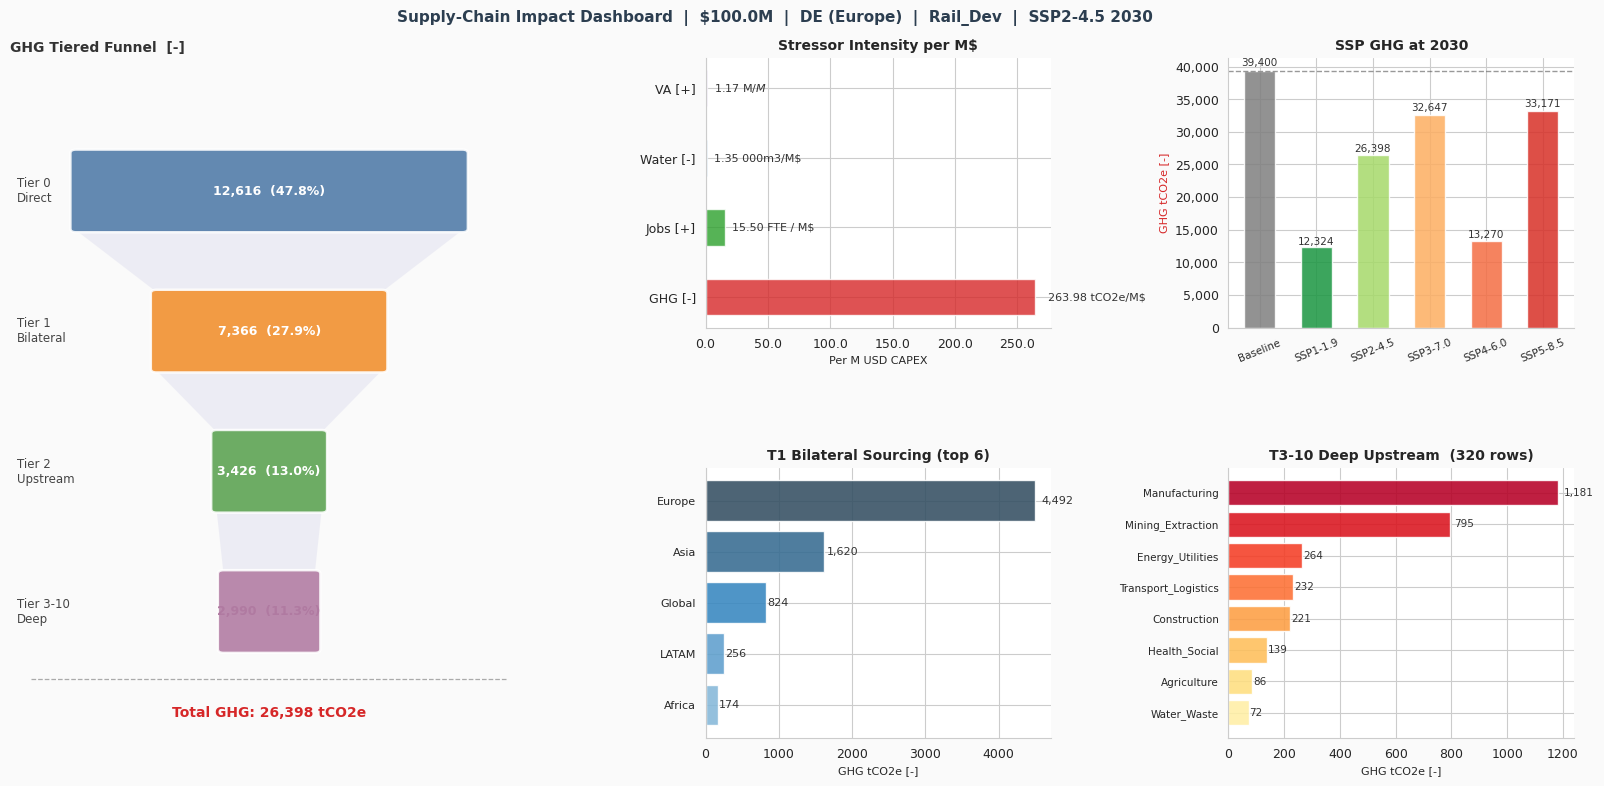

Dashboard saved -> results/dashboard_Rail_Dev_Europe_100p0M_SSP245.png


In [12]:
# ══════════════════════════════════════════════════════════════════
# SECTION 7 — STATIC SUMMARY DASHBOARD  (Matplotlib / Seaborn)
# Static tiered funnel + 4 panels — honest alternative to Sankey
# when >5 sourcing regions make the interactive view cluttered.
# ══════════════════════════════════════════════════════════════════
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Polygon, FancyBboxPatch
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
})

TIER_COLORS_MPL = ["#4e79a7", "#f28e2b", "#59a14f", "#b07aa1"]
SSP_COLORS_MPL  = {
    "SSP1-1.9": "#1a9641", "SSP2-4.5": "#a6d96a",
    "SSP3-7.0": "#fdae61", "SSP4-6.0": "#f46d43", "SSP5-8.5": "#d73027",
}

# ── Data prep ──────────────────────────────────────────────────────────────
_tier_labels = ["Tier 0\nDirect", "Tier 1\nBilateral",
                "Tier 2\nUpstream", "Tier 3-10\nDeep"]
_tier_dfs    = [t0, t1, t2, t3]
COLS_ALL     = ["GHG_tCO2e", "Employment_FTE", "Water_1000m3", "ValueAdded_M$"]

_tier_vals  = {}
_sc_totals  = {}

for _col in COLS_ALL:
    _v = [_apply(_df[_col].sum() if _col in _df.columns else 0, _col, FACTORS)
          for _df in _tier_dfs]
    _tier_vals[_col]  = _v
    _sc_totals[_col]  = sum(_v)

_capex_musd = CAPEX_USD / 1e6

# ── Figure layout ──────────────────────────────────────────────────────────
fig_dash = plt.figure(figsize=(17, 8), facecolor="#fafafa")
fig_dash.suptitle(
    (f"Supply-Chain Impact Dashboard  |  {fmt_capex(CAPEX_USD)}  |  "
     f"{COUNTRY} ({REGION})  |  {SECTOR}  |  {sc_label}"),
    fontsize=11, fontweight="bold", y=0.99, color="#2c3e50"
)

gs = gridspec.GridSpec(
    2, 3, figure=fig_dash,
    left=0.05, right=0.97, top=0.93, bottom=0.08,
    hspace=0.52, wspace=0.44,
    width_ratios=[1.5, 1, 1],
)

ax_funnel = fig_dash.add_subplot(gs[:, 0])
ax_kpi    = fig_dash.add_subplot(gs[0, 1])
ax_ssp    = fig_dash.add_subplot(gs[0, 2])
ax_bilat  = fig_dash.add_subplot(gs[1, 1])
ax_deep   = fig_dash.add_subplot(gs[1, 2])

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 1 — Tiered GHG Funnel
# Each tier is a centred horizontal bar; width proportional to GHG.
# Grey trapezia connect adjacent bars for the funnel-taper effect.
# ═══════════════════════════════════════════════════════════════════════════
_ghg_vals  = _tier_vals["GHG_tCO2e"]
_ghg_total = _sc_totals["GHG_tCO2e"]
_max_v     = max(abs(v) for v in _ghg_vals) or 1

n_tiers = len(_tier_labels)
y_pos   = list(range(n_tiers - 1, -1, -1))   # T0 at top

ax_funnel.set_xlim(-1.18, 1.18)
ax_funnel.set_ylim(-0.90, n_tiers - 0.05)
ax_funnel.axis("off")

half_widths = [(abs(v) / _max_v) * 0.88 for v in _ghg_vals]

# Trapezia
for i in range(n_tiers - 1):
    yi_top = y_pos[i]
    yi_bot = y_pos[i + 1]
    hw_hi  = half_widths[i]
    hw_lo  = half_widths[i + 1]
    trap = Polygon(
        [(-hw_hi, yi_top - 0.28), ( hw_hi, yi_top - 0.28),
         ( hw_lo, yi_bot + 0.28), (-hw_lo, yi_bot + 0.28)],
        closed=True, facecolor="#dde", edgecolor="none", alpha=0.45, zorder=0
    )
    ax_funnel.add_patch(trap)

# Rounded bars
for y, label, v, color, hw in zip(
        y_pos, _tier_labels, _ghg_vals, TIER_COLORS_MPL, half_widths):
    rect = FancyBboxPatch(
        (-hw, y - 0.27), 2 * hw, 0.54,
        boxstyle="round,pad=0.025",
        facecolor=color, edgecolor="white", linewidth=1.8,
        alpha=0.88, zorder=1
    )
    ax_funnel.add_patch(rect)

    pct     = v / _ghg_total * 100 if _ghg_total else 0
    txt_col = "white" if hw > 0.22 else color
    ax_funnel.text(0, y, f"{v:,.0f}  ({pct:.1f}%)",
                   ha="center", va="center",
                   fontsize=9, fontweight="bold", color=txt_col, zorder=2)
    ax_funnel.text(-1.15, y, label,
                   ha="left", va="center", fontsize=8.5, color="#444")

ax_funnel.axhline(-0.48, xmin=0.04, xmax=0.96,
                  color="#aaa", linewidth=0.9, linestyle="--")
ax_funnel.text(0, -0.72, f"Total GHG: {_ghg_total:,.0f} tCO2e",
               ha="center", va="center",
               fontsize=10, fontweight="bold", color="#d62728")
ax_funnel.set_title("GHG Tiered Funnel  [-]",
                    fontsize=10, fontweight="bold", pad=4, color="#333", loc="left")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 2 — Stressor Intensity per M USD CAPEX
# ═══════════════════════════════════════════════════════════════════════════
_smeta = [
    ("GHG_tCO2e",      "GHG [-]",  "tCO2e/M$",  "#d62728"),
    ("Employment_FTE", "Jobs [+]",  "FTE / M$",   "#2ca02c"),
    ("Water_1000m3",   "Water [-]", "000m3/M$",   "#1f77b4"),
    ("ValueAdded_M$",  "VA [+]",    "M$ / M$",    "#9467bd"),
]
_intens  = [_sc_totals[c] / _capex_musd for c, *_ in _smeta]
_klabels = [m[1] for m in _smeta]
_kcolors = [m[3] for m in _smeta]
_kunits  = [m[2] for m in _smeta]

_bk = ax_kpi.barh(_klabels, _intens, color=_kcolors,
                   alpha=0.80, edgecolor="white", height=0.52)
for _b, _val, _unit in zip(_bk, _intens, _kunits):
    ax_kpi.text(_b.get_width() * 1.02,
                _b.get_y() + _b.get_height() / 2,
                f"  {_val:,.2f} {_unit}",
                va="center", fontsize=8, color="#333")
ax_kpi.set_xlabel("Per M USD CAPEX", fontsize=8)
ax_kpi.set_title("Stressor Intensity per M$", fontsize=10, fontweight="bold")
ax_kpi.tick_params(axis="y", labelsize=9)
ax_kpi.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.1f}"))
ax_kpi.spines[["top", "right"]].set_visible(False)

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 3 — SSP GHG Comparison
# ═══════════════════════════════════════════════════════════════════════════
_ssps_ok = [s for s in ALL_SSPS if ALL_FACTORS.get(s)]

if COMPARE_SSPS and _ssps_ok:
    def _tot(col, f):
        return sum(_apply(_df[col].sum() if col in _df.columns else 0, col, f)
                   for _df in _tier_dfs)

    _ssp_lbl = ["Baseline"] + _ssps_ok
    _ssp_ghg = [_tot("GHG_tCO2e", None)] + \
               [_tot("GHG_tCO2e", ALL_FACTORS[s]) for s in _ssps_ok]
    _ssp_clr = ["#7f7f7f"] + [SSP_COLORS_MPL[s] for s in _ssps_ok]

    _bs = ax_ssp.bar(_ssp_lbl, _ssp_ghg, color=_ssp_clr,
                     alpha=0.85, edgecolor="white", width=0.55)
    for _b, _val in zip(_bs, _ssp_ghg):
        ax_ssp.text(_b.get_x() + _b.get_width() / 2,
                    _b.get_height() * 1.01,
                    f"{_val:,.0f}", ha="center", va="bottom",
                    fontsize=7.5, color="#333")
    ax_ssp.axhline(_ssp_ghg[0], color="#555", linewidth=1,
                   linestyle="--", alpha=0.6)
    ax_ssp.set_ylabel("GHG tCO2e [-]", fontsize=8, color="#d62728")
    ax_ssp.set_title(f"SSP GHG at {FOCUS_YEAR}", fontsize=10, fontweight="bold")
    ax_ssp.tick_params(axis="x", labelsize=7.5, rotation=22)
    ax_ssp.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_ssp.spines[["top", "right"]].set_visible(False)
else:
    ax_ssp.text(0.5, 0.5, "No scenario\ndata available",
                ha="center", va="center",
                transform=ax_ssp.transAxes, fontsize=11, color="#aaa")
    ax_ssp.set_title("SSP Comparison", fontsize=10, fontweight="bold")
    ax_ssp.axis("off")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 4 — Tier 1 Bilateral Sourcing  (top 6 regions by GHG)
# ═══════════════════════════════════════════════════════════════════════════
_bilat = (t1.groupby("sourcing_region")["GHG_tCO2e"]
            .sum()
            .apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
            .sort_values(ascending=True)
            .tail(6))

if not _bilat.empty and _bilat.sum() > 0:
    _bc = sns.color_palette("Blues_d", len(_bilat))
    ax_bilat.barh(_bilat.index, _bilat.values, color=_bc,
                  alpha=0.88, edgecolor="white")
    for _i, (_n, _val) in enumerate(_bilat.items()):
        ax_bilat.text(_val * 1.02, _i, f"{_val:,.0f}",
                      va="center", fontsize=8, color="#333")
    ax_bilat.set_xlabel("GHG tCO2e [-]", fontsize=8)
    ax_bilat.set_title("T1 Bilateral Sourcing (top 6)", fontsize=10, fontweight="bold")
    ax_bilat.tick_params(axis="y", labelsize=8)
    ax_bilat.spines[["top", "right"]].set_visible(False)
else:
    ax_bilat.text(0.5, 0.5, "No T1 GHG data",
                  ha="center", va="center", transform=ax_bilat.transAxes, color="#aaa")
    ax_bilat.axis("off")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 5 — Deep Upstream T3-10  (top 8 sectors by GHG)
# ═══════════════════════════════════════════════════════════════════════════
if "GHG_tCO2e" in t3.columns and t3["GHG_tCO2e"].sum() > 0:
    _deep = (t3.groupby("supplying_sector")["GHG_tCO2e"]
               .sum()
               .apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
               .sort_values(ascending=True)
               .tail(8))
    _dc = sns.color_palette("YlOrRd", len(_deep))
    ax_deep.barh(_deep.index, _deep.values, color=_dc,
                 alpha=0.88, edgecolor="white")
    for _i, (_n, _val) in enumerate(_deep.items()):
        ax_deep.text(_val * 1.02, _i, f"{_val:,.0f}",
                     va="center", fontsize=7.5, color="#333")
    ax_deep.set_xlabel("GHG tCO2e [-]", fontsize=8)
    ax_deep.set_title(
        f"T3-10 Deep Upstream  ({len(t3)} rows)",
        fontsize=10, fontweight="bold"
    )
    ax_deep.tick_params(axis="y", labelsize=7.5)
    ax_deep.spines[["top", "right"]].set_visible(False)
else:
    ax_deep.text(0.5, 0.5, "No T3-10\nGHG data",
                 ha="center", va="center", transform=ax_deep.transAxes, color="#aaa")
    ax_deep.axis("off")

# ── Save + display ─────────────────────────────────────────────────────────
_slug = (f"dashboard_{SECTOR}_{REGION}_"
         f"{fmt_capex(CAPEX_USD).replace('$','').replace('.','p')}"
         f"{'_'+SCENARIO.replace('.','').replace('-','') if SCENARIO else ''}.png")
RESULTS_DIR.mkdir(exist_ok=True)
fig_dash.savefig(RESULTS_DIR / _slug, dpi=150,
                 bbox_inches="tight", facecolor="#fafafa")
plt.tight_layout()
plt.show()
print(f"Dashboard saved -> results/{_slug}")


In [13]:
# ══════════════════════════════════════════════════════════════════
# PART B — NATURE DEPENDENCY OVERLAY  (Sections 8–14)
# ══════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════
# SECTION 8 — ENCORE MATERIALITY HEATMAP
# Shows ecosystem dependency (left) and impact (right) for the
# project sector, sorted by combined materiality score.
# ══════════════════════════════════════════════════════════════════
profile = get_materiality_profile(ENCORE_SECTOR)
mat     = profile.summary_table()   # sorted by dep+impact score

svc_labels = [r["ecosystem_service"].replace("_"," ").title() for r in mat]
dep_scores = [r["dependency_score"]  for r in mat]
imp_scores = [r["impact_score"]      for r in mat]
dep_labels = [r["dependency_rating"] for r in mat]
imp_labels = [r["impact_rating"]     for r in mat]
material   = [r["material"]          for r in mat]

# Heatmap: rows = ecosystem services, cols = [Dependency, Impact]
Z    = [[d, i] for d, i in zip(dep_scores, imp_scores)]
TEXT = [[f"<b>{dl}</b>", f"<b>{il}</b>"] for dl, il in zip(dep_labels, imp_labels)]

svc_colors = ["#fff3cd" if m else "#f8f9fa" for m in material]  # highlight material rows

fig_enc = go.Figure()
fig_enc.add_trace(go.Heatmap(
    z=Z, x=["Dependency", "Impact"], y=svc_labels,
    text=TEXT, texttemplate="%{text}",
    textfont=dict(size=10),
    colorscale=[
        [0.0,  "#f0f0f0"],
        [0.2,  "#c7e9c0"],
        [0.4,  "#74c476"],
        [0.6,  "#fdae6b"],
        [0.8,  "#e6550d"],
        [1.0,  "#7f0000"],
    ],
    zmin=0, zmax=5,
    colorbar=dict(title="Score (0-5)", tickvals=[0,1,2,3,4,5],
                  ticktext=["N","VL","L","M","H","VH"]),
))

# Stressor-relevant services
for stressor, svcs in STRESSOR_ECOSYSTEM_MAP.items():
    for svc in svcs:
        label = svc.replace("_"," ").title()
        if label in svc_labels:
            idx = svc_labels.index(label)

fig_enc.update_layout(
    title=dict(
        text=(f"<b>ENCORE Materiality — {ENCORE_SECTOR.replace('_',' ').title()}</b>"
              f"<br><span style='font-size:11px;color:#555'>"
              f"Yellow rows = material (dep or impact >= High). "
              f"Stressor-relevant services are marked by their score color.</span>"),
        x=0.01, xanchor="left", font=dict(size=14)),
    height=620,
    margin=dict(l=220, r=120, t=90, b=40),
    yaxis=dict(autorange="reversed"),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10),
)
display(HTML(fig_enc.to_html(full_html=False, include_plotlyjs="cdn")))


In [14]:
# ══════════════════════════════════════════════════════════════════
# SECTION 9 — WWF RISK BY SOURCING REGION
# WRF (Water Risk) + BRF (Biodiversity Risk) per region:
# main investment region + all T1 bilateral sourcing regions.
# Red dashed line = high-risk threshold (3.4).
# ══════════════════════════════════════════════════════════════════
# Collect regions to show: main + T1
_t1_regions = (t1["sourcing_region"].unique().tolist()
               if not t1.empty else [])
_all_regions = [REGION] + [r for r in _t1_regions if r != REGION]
_all_regions = _all_regions[:6]   # cap at 6 for readability

WRF_KEYS = ["wrf_physical","wrf_regulatory","wrf_reputational"]
BRF_KEYS = ["brf_species_threat","brf_ecosystem","brf_protected_areas"]
WRF_LABELS = ["Physical","Regulatory","Reputational"]
BRF_LABELS = ["Species Threat","Ecosystem Intactness","Protected Areas"]
RISK_COLORS = ["#e6550d","#fdae6b","#74c476","#31a354","#006d2c"]

fig_wwf = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Water Risk Filter (WRF) — Physical/Reg/Rep",
                    "Biodiversity Risk Filter (BRF) — Species/Eco/PA"],
    shared_yaxes=False,
)

reg_colors = ["#4e79a7","#f28e2b","#59a14f","#b07aa1","#e15759","#76b7b2"]

for ri, reg in enumerate(_all_regions):
    wdata = get_wwf(reg)
    rc    = reg_colors[ri % len(reg_colors)]
    wrf_v = [wdata.get(k, 0) for k in WRF_KEYS]
    brf_v = [wdata.get(k, 0) for k in BRF_KEYS]
    flag  = "(main)" if reg == REGION else f"(T1)"

    fig_wwf.add_trace(go.Bar(
        name=f"{reg} {flag}", x=WRF_LABELS, y=wrf_v,
        marker_color=rc, opacity=0.82,
        text=[f"{v:.2f}" for v in wrf_v],
        textposition="outside", textfont=dict(size=8),
        legendgroup=reg,
    ), row=1, col=1)

    fig_wwf.add_trace(go.Bar(
        name=f"{reg} {flag}", x=BRF_LABELS, y=brf_v,
        marker_color=rc, opacity=0.82,
        text=[f"{v:.2f}" for v in brf_v],
        textposition="outside", textfont=dict(size=8),
        legendgroup=reg, showlegend=False,
    ), row=1, col=2)

# High-risk threshold line
for col in [1, 2]:
    fig_wwf.add_hline(
        y=DEP_THRESHOLD, line_dash="dash", line_color="red",
        line_width=1.5, annotation_text="High Risk 3.4",
        annotation_font=dict(color="red", size=9),
        row=1, col=col,
    )

fig_wwf.update_layout(
    title=dict(
        text=(f"<b>WWF Risk Filter Scores by Region</b>"
              f"<br><span style='font-size:11px;color:#555'>"
              f"{COUNTRY} ({REGION}) · {SECTOR} · {sc_label}</span>"),
        x=0.01, xanchor="left", font=dict(size=14)),
    barmode="group",
    height=420,
    yaxis=dict(range=[0, 5.8], title="Score (1-5)"),
    yaxis2=dict(range=[0, 5.8], title="Score (1-5)"),
    legend=dict(orientation="h", y=1.12),
    margin=dict(l=60, r=40, t=100, b=50),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10),
)
display(HTML(fig_wwf.to_html(full_html=False, include_plotlyjs="cdn")))


In [15]:
# ══════════════════════════════════════════════════════════════════
# SECTION 10 — DEPENDENCY FACTOR BY TIER × STRESSOR
# dep_factor = (ENCORE/3 + WWF/3 + SC-sector/3) / 3  (neutral=1.0)
# >1.0: nature conditions amplify the stressor's risk exposure.
# <1.0: low dependency / low regional risk — dampening effect.
# ══════════════════════════════════════════════════════════════════
_tier_keys    = ["t0","t1","t2","t3"]
_tier_names   = ["Tier 0  Direct","Tier 1  Bilateral",
                 "Tier 2  Upstream","Tier 3-10  Deep"]
_tier_colors  = ["#4e79a7","#f28e2b","#59a14f","#b07aa1"]
_str3 = [("GHG_tCO2e","GHG","#d62728"),
         ("Employment_FTE","Employment","#2ca02c"),
         ("Water_1000m3","Water","#1f77b4")]

fig_df = go.Figure()
for sc_col, sc_name, sc_color in _str3:
    x_labels, y_vals, bar_colors = [], [], []
    for tk, tn in zip(_tier_keys, _tier_names):
        df_val = TIER_DEP[tk][sc_col]
        x_labels.append(tn)
        y_vals.append(df_val)
        bar_colors.append(
            "#d62728" if df_val > 1.15 else
            "#fdae6b" if df_val > 1.0  else
            "#74c476" if df_val < 0.9  else "#aec7e8"
        )
    fig_df.add_trace(go.Bar(
        name=sc_name, x=x_labels, y=y_vals,
        marker_color=sc_color, opacity=0.80,
        text=[f"{v:.3f}" for v in y_vals],
        textposition="outside",
        textfont=dict(size=9),
    ))

fig_df.add_hline(
    y=1.0, line_dash="dot", line_color="#333",
    line_width=2,
    annotation_text="Neutral (1.0)", annotation_position="top right",
    annotation_font=dict(size=9, color="#333"),
)
fig_df.add_hrect(y0=1.0, y1=1.67, fillcolor="#ffe0e0", opacity=0.15,
                  annotation_text="Amplifying zone",
                  annotation_position="top right",
                  annotation_font=dict(size=8, color="#c00"))
fig_df.add_hrect(y0=0.33, y1=1.0, fillcolor="#e0ffe0", opacity=0.15,
                  annotation_text="Dampening zone",
                  annotation_position="bottom right",
                  annotation_font=dict(size=8, color="#060"))

fig_df.update_layout(
    title=dict(
        text=(f"<b>Dependency Factor by Tier</b>"
              f"<br><span style='font-size:11px;color:#555'>"
              f"Three-component dep_factor (ENCORE + WWF + SC-sector) — "
              f"neutral=1.0, range approx 0.33-1.67</span>"),
        x=0.01, xanchor="left", font=dict(size=14)),
    barmode="group",
    yaxis=dict(title="dep_factor", range=[0, max(
        max(TIER_DEP[tk][c] for c,*_ in _str3) for tk in _tier_keys
    ) * 1.25 + 0.05]),
    height=400,
    legend=dict(orientation="h", y=1.10),
    margin=dict(l=70, r=60, t=100, b=70),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11),
)
display(HTML(fig_df.to_html(full_html=False, include_plotlyjs="cdn")))


In [16]:
# ══════════════════════════════════════════════════════════════════
# SECTION 11 — DEPENDENCY-WEIGHTED SANKEY
# Same 3-stressor, 4-tier structure as investment_sankey.ipynb,
# but link/node values carry the dep_factor weight:
#   flow = scenario_adj × dep_factor(row)
# Node colour intensity darkens when dep_factor > 1.0.
# ══════════════════════════════════════════════════════════════════
def _top_n(s, n=TOP_N):
    s = s[s > 0]
    if len(s) <= n: return s
    top  = s.nlargest(n)
    rest = s[~s.index.isin(top.index)].sum()
    return pd.concat([top, pd.Series({"Other": rest})]) if rest > 0 else top

def _dep_sankey(col):
    nodes, nc = [], []
    src_l, tgt_l, val_l, lc_l = [], [], [], []

    def node(lbl, color):
        if lbl not in nodes: nodes.append(lbl); nc.append(color)
        return nodes.index(lbl)

    meta   = next(m for m in STRESSORS if m[0] == col)
    sname, sunit, s_col, ssign = meta[1], meta[2], meta[3], meta[4]

    # Per-row dep-weighted values ────────────────────────────────────
    def _dw_row(df, sreg_col=None):
        if df.empty or col not in df.columns: return pd.Series(dtype=float)
        rows = []
        for _, row in df.iterrows():
            sreg = row.get(sreg_col, REGION) if sreg_col else REGION
            sec  = row.get("supplying_sector", "Unknown")
            dw   = _apply(row[col], col, FACTORS) * dep_factor(col, sreg, sec)
            rows.append((sec, dw))
        s = pd.Series(dict(rows))
        return s.groupby(s.index).sum()

    def _dw_grouped(df, group_col, sreg_col=None):
        if df.empty or col not in df.columns: return pd.Series(dtype=float)
        result = {}
        for _, row in df.iterrows():
            key  = row.get(group_col, "Unknown")
            sreg = row.get(sreg_col, REGION) if sreg_col else REGION
            sec  = row.get("supplying_sector", "Unknown")
            dw   = _apply(row[col], col, FACTORS) * dep_factor(col, sreg, sec)
            result[key] = result.get(key, 0) + dw
        return pd.Series(result)

    t0_dw = _dw_row(t0)
    t1_dw = _dw_grouped(t1, "sourcing_region", "sourcing_region")
    t2_dw = _dw_row(t2)
    t3_dw = _dw_row(t3)

    grand = sum(s.sum() for s in [t0_dw, t1_dw, t2_dw, t3_dw] if not s.empty)

    df0 = TIER_DEP["t0"][col]
    df1 = TIER_DEP["t1"][col]
    df2 = TIER_DEP["t2"][col]
    df3 = TIER_DEP["t3"][col]

    def _darken(hex_col, factor):
        import re
        h = hex_col.lstrip("#")
        r,g,b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
        r = min(255, max(0, int(r * (2 - factor))))
        g = min(255, max(0, int(g * (2 - factor))))
        b = min(255, max(0, int(b * (2 - factor))))
        return f"#{r:02x}{g:02x}{b:02x}"

    i0 = node("Tier 0\nDirect CAPEX",      _darken(TIER_NODE["t0"], df0))
    i1 = node("Tier 1\nBilateral",         _darken(TIER_NODE["t1"], df1))
    i2 = node("Tier 2\nUpstream",          _darken(TIER_NODE["t2"], df2))
    i3 = node("Tier 3-10\nDeep Upstream",  _darken(TIER_NODE["t3"], df3))
    term = node(f"{sname}\n{grand:,.0f} {sunit}\n(dep-weighted)", s_col)

    def add_flows(tier_idx, breakdown, tk):
        for name, v in _top_n(breakdown).items():
            mid = node(name, INTER[tk])
            src_l.extend([tier_idx, mid]); tgt_l.extend([mid, term])
            val_l.extend([v, v]);          lc_l.extend([TIER_LINK[tk]]*2)

    add_flows(i0, t0_dw, "t0")
    add_flows(i1, t1_dw, "t1")
    if t2_dw.sum() > 0: add_flows(i2, t2_dw, "t2")
    if t3_dw.sum() > 0: add_flows(i3, t3_dw, "t3")

    return dict(nodes=nodes, nc=nc, src=src_l, tgt=tgt_l, val=val_l, lc=lc_l,
                grand=grand, sname=sname, sunit=sunit, s_col=s_col, ssign=ssign)

n_s, gap = len(STRESSORS), 0.03
w = (1.0 - gap*(n_s-1)) / n_s
fig_sk = go.Figure()

for i, (col, *_) in enumerate(STRESSORS):
    d   = _dep_sankey(col)
    x0  = i*(w+gap); x1 = x0+w
    fig_sk.add_trace(go.Sankey(
        domain=dict(x=[x0,x1], y=[0,0.90]),
        arrangement="snap",
        node=dict(label=d["nodes"], color=d["nc"], pad=14, thickness=18,
                  line=dict(color="white", width=0.4)),
        link=dict(source=d["src"], target=d["tgt"],
                  value=d["val"], color=d["lc"]),
    ))
    fig_sk.add_annotation(
        x=(x0+x1)/2, y=1.0, xref="paper", yref="paper",
        text=(f"<b>{d['ssign']} {d['sname']}</b><br>"
              f"<span style='font-size:11px;color:{d['s_col']}'>"
              f"{d['grand']:,.0f} {d['sunit']} dep-wtd</span>"),
        showarrow=False, font=dict(size=13), align="center")

fig_sk.update_layout(
    title=dict(
        text=(f"<b>Dependency-Weighted Supply-Chain Sankey — {sc_label}</b>"
              f"<br><span style='font-size:11px;color:#555'>"
              f"Flow values = scenario_adj x dep_factor(tier,region,sector) | "
              f"Darker nodes = higher dep_factor</span>"),
        x=0.01, xanchor="left", font=dict(size=14)),
    height=600,
    margin=dict(l=20, r=20, t=105, b=20),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10),
)
display(HTML(fig_sk.to_html(full_html=False, include_plotlyjs="cdn")))


In [17]:
# ══════════════════════════════════════════════════════════════════
# SECTION 12 — THREE-LAYER TIER COMPARISON
# For each tier: Raw | Scenario-Adjusted | Dependency-Weighted
# GHG (bars, left axis) + Employment (line, right axis).
# ══════════════════════════════════════════════════════════════════
_tier_keys  = ["t0","t1","t2","t3"]
_tier_short = ["T0 Direct","T1 Bilateral","T2 Upstream","T3-10 Deep"]
_layers = [
    ("raw", "Raw (Baseline)",        0.45, "///"),
    ("adj", f"Adj ({sc_label})",     0.70, None),
    ("dep", "Dep-Weighted",          1.00, None),
]
_layer_offsets = [-0.22, 0, 0.22]
_ghg_bar_colors = ["#aec7e8", "#6baed6", "#2171b5"]
_emp_marker_symbols = ["circle-open", "circle", "diamond"]

fig_3l = make_subplots(specs=[[{"secondary_y": True}]])

for li, (layer, lname, alpha, pattern) in enumerate(_layers):
    ghg_vals = [SUMMARY[tk][layer]["GHG_tCO2e"] for tk in _tier_keys]
    emp_vals = [SUMMARY[tk][layer]["Employment_FTE"] for tk in _tier_keys]

    fig_3l.add_trace(go.Bar(
        name=lname,
        x=_tier_short,
        y=ghg_vals,
        marker_color=_ghg_bar_colors[li],
        opacity=alpha,
        text=[f"{v:,.0f}" if v > 0 else "" for v in ghg_vals],
        textposition="inside", insidetextanchor="middle",
        textfont=dict(size=8, color="white"),
        offsetgroup=li,
    ), secondary_y=False)

    fig_3l.add_trace(go.Scatter(
        name=f"Employment {lname}",
        x=_tier_short, y=emp_vals,
        mode="lines+markers+text",
        line=dict(color=["#a1d99b","#41ab5d","#006d2c"][li],
                  width=2, dash=["dash","dot","solid"][li]),
        marker=dict(size=8, symbol=_emp_marker_symbols[li]),
        text=[f"{v:,.0f}" if v > 0 else "" for v in emp_vals],
        textposition="top center", textfont=dict(size=8),
        showlegend=True,
    ), secondary_y=True)

fig_3l.update_layout(
    title=dict(
        text=(f"<b>Three-Layer Tier Comparison</b>"
              f"<br><span style='font-size:11px;color:#555'>"
              f"GHG bars [-] (left) · Employment lines [+] (right) · "
              f"{fmt_capex(CAPEX_USD)} · {COUNTRY}</span>"),
        x=0.01, xanchor="left", font=dict(size=14)),
    barmode="group",
    height=440,
    legend=dict(orientation="h", y=1.14, font=dict(size=9)),
    margin=dict(l=80, r=80, t=110, b=60),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11),
)
fig_3l.update_yaxes(title_text="GHG tCO2e [-]", secondary_y=False, title_font_color="#d62728")
fig_3l.update_yaxes(title_text="Employment FTE [+]", secondary_y=True, title_font_color="#2ca02c")
display(HTML(fig_3l.to_html(full_html=False, include_plotlyjs="cdn")))


In [18]:
# ══════════════════════════════════════════════════════════════════
# SECTION 13 — T1 BILATERAL SOURCING × NATURE RISK
# Bars = dep-weighted GHG by sourcing region.
# Bar colour = WRF physical score (green-yellow-red scale).
# Scatter = raw GHG (open circles) to show dep amplification.
# ══════════════════════════════════════════════════════════════════
if t1.empty or "sourcing_region" not in t1.columns:
    print("No Tier 1 bilateral data available.")
else:
    _t1_raw_by_reg  = (t1.groupby("sourcing_region")["GHG_tCO2e"]
                         .sum()
                         .apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS)))
    _t1_dep_by_reg  = {}
    for reg, grp in t1.groupby("sourcing_region"):
        dw = sum(
            _apply(row["GHG_tCO2e"], "GHG_tCO2e", FACTORS)
            * dep_factor("GHG_tCO2e", reg, row["supplying_sector"])
            for _, row in grp.iterrows()
        )
        _t1_dep_by_reg[reg] = dw
    _t1_dep_ser = pd.Series(_t1_dep_by_reg).sort_values(ascending=True)

    _wrf_scores = {reg: get_wwf(reg).get("wrf_physical", DEP_NEUTRAL)
                   for reg in _t1_dep_ser.index}
    _max_wrf    = max(_wrf_scores.values()) or 1

    def _wrf_color(score):
        t = min(1.0, score / 5.0)
        r = int(255 * t);  g = int(180 * (1 - t)); b = 50
        return f"rgb({r},{g},{b})"

    bar_colors = [_wrf_color(_wrf_scores[r]) for r in _t1_dep_ser.index]

    fig_bil = go.Figure()
    fig_bil.add_trace(go.Bar(
        name="Dep-Weighted GHG",
        x=_t1_dep_ser.values, y=_t1_dep_ser.index,
        orientation="h",
        marker_color=bar_colors, marker_line_color="white", marker_line_width=1,
        text=[f"{v:,.0f}" for v in _t1_dep_ser.values],
        textposition="outside",
        textfont=dict(size=9),
    ))
    # Raw GHG overlay
    _raw_aligned = _t1_raw_by_reg.reindex(_t1_dep_ser.index, fill_value=0)
    fig_bil.add_trace(go.Scatter(
        name="Adj GHG (no dep)",
        x=_raw_aligned.values, y=_t1_dep_ser.index,
        mode="markers",
        marker=dict(symbol="line-ns", size=14, color="#333",
                    line=dict(width=2, color="#333")),
    ))

    # Colourbar legend
    fig_bil.add_trace(go.Scatter(
        x=[None], y=[None], mode="markers",
        marker=dict(
            colorscale=[[0,"#00b450"],[0.5,"#fdae00"],[1.0,"#d62728"]],
            showscale=True,
            colorbar=dict(title="WRF Physical", x=1.02,
                          tickvals=[0,2.5,5], ticktext=["Low","Med","High"]),
            cmin=0, cmax=5,
            color=[_wrf_scores[r] for r in _t1_dep_ser.index],
            size=8,
        ),
        showlegend=False,
    ))

    fig_bil.update_layout(
        title=dict(
            text=(f"<b>Tier 1 Bilateral × Nature Risk</b>"
                  f"<br><span style='font-size:11px;color:#555'>"
                  f"Bar = dep-weighted GHG | Bar colour = WRF physical score | "
                  f"Vertical line = adj GHG without dep weight</span>"),
            x=0.01, xanchor="left", font=dict(size=14)),
        xaxis_title="GHG tCO2e",
        height=360,
        legend=dict(orientation="h", y=1.12),
        margin=dict(l=100, r=80, t=100, b=50),
        paper_bgcolor="#fafafa", font=dict(family="Arial", size=11),
    )
    display(HTML(fig_bil.to_html(full_html=False, include_plotlyjs="cdn")))


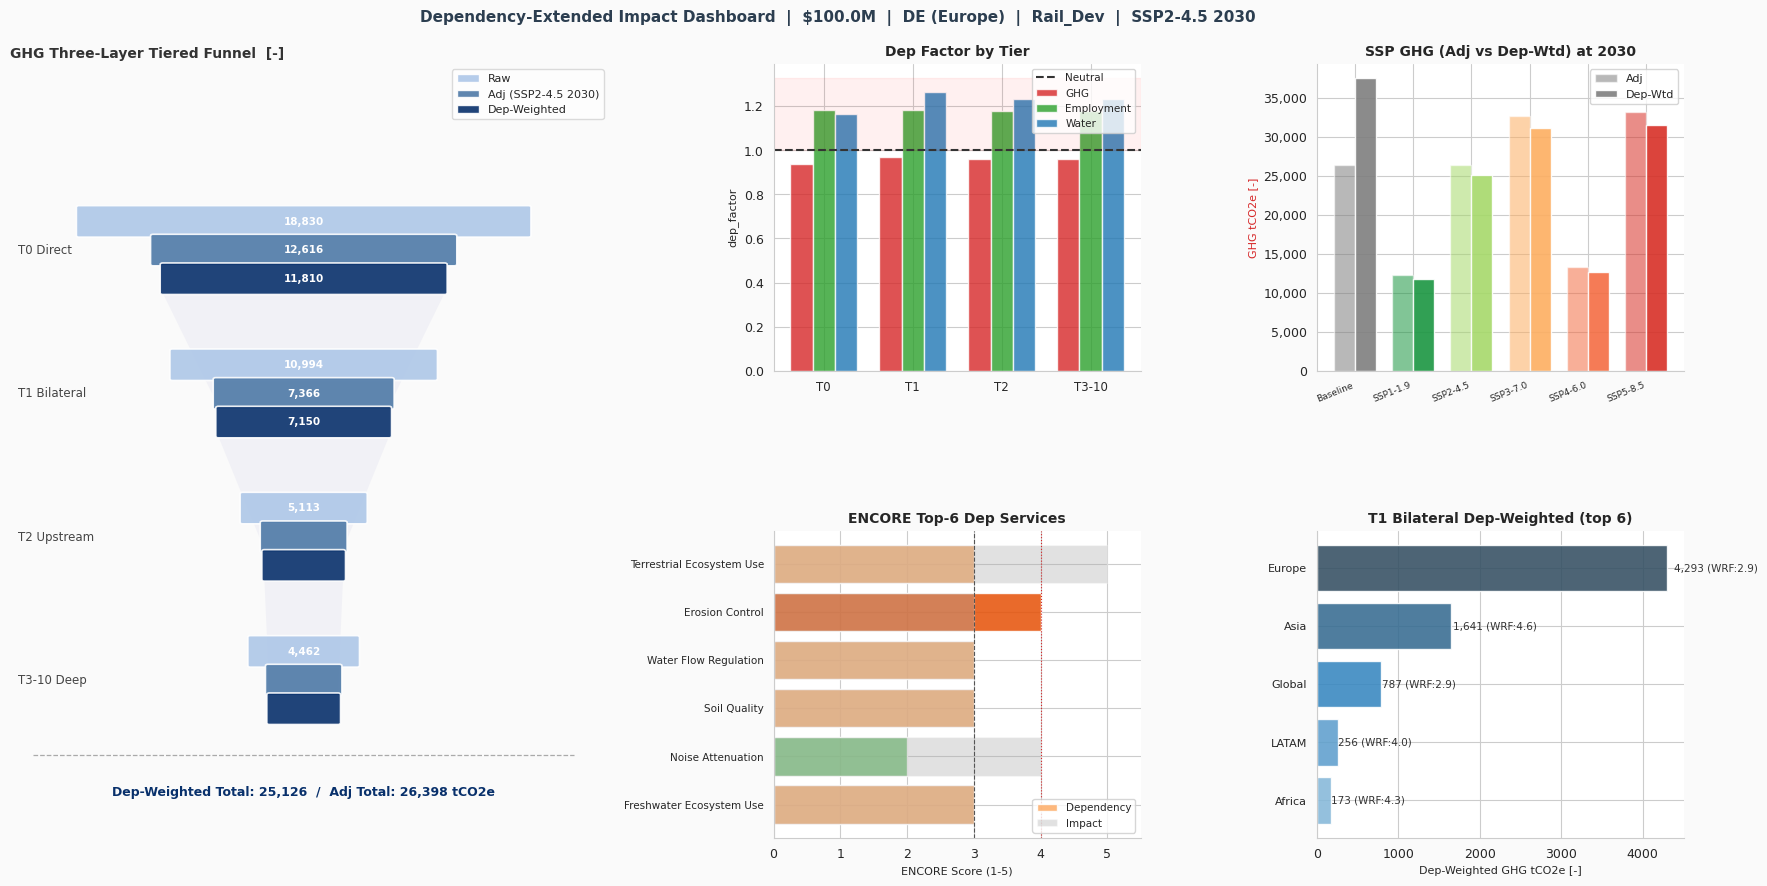

Dashboard saved -> results/dep_dashboard_Rail_Dev_Europe_100p0M_SSP245.png


In [19]:
# ══════════════════════════════════════════════════════════════════
# SECTION 14 — STATIC SUMMARY DASHBOARD  (Matplotlib)
# Three-layer tiered funnel (raw / adj / dep-weighted) + 4 panels.
# ══════════════════════════════════════════════════════════════════
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, Polygon
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})

TIER_COLORS_MPL = ["#4e79a7","#f28e2b","#59a14f","#b07aa1"]
LAYER_COLORS    = {"raw": "#aec7e8", "adj": "#4e79a7", "dep": "#08306b"}
LAYER_LABELS    = {"raw": "Raw", "adj": f"Adj ({sc_label})", "dep": "Dep-Weighted"}
_tier_keys  = ["t0","t1","t2","t3"]
_tier_short = ["T0 Direct","T1 Bilateral","T2 Upstream","T3-10 Deep"]

# ── Layout ─────────────────────────────────────────────────────────────────
fig_d = plt.figure(figsize=(18, 9), facecolor="#fafafa")
fig_d.suptitle(
    (f"Dependency-Extended Impact Dashboard  |  {fmt_capex(CAPEX_USD)}  |  "
     f"{COUNTRY} ({REGION})  |  {SECTOR}  |  {sc_label}"),
    fontsize=11, fontweight="bold", y=0.99, color="#2c3e50",
)
gs = gridspec.GridSpec(
    2, 3, figure=fig_d,
    left=0.04, right=0.97, top=0.93, bottom=0.07,
    hspace=0.52, wspace=0.40,
    width_ratios=[1.6, 1, 1],
)
ax_funnel = fig_d.add_subplot(gs[:, 0])   # left full-height: three-layer funnel
ax_df     = fig_d.add_subplot(gs[0, 1])   # top-mid: dep factor by tier
ax_ssp    = fig_d.add_subplot(gs[0, 2])   # top-right: SSP comparison
ax_enc    = fig_d.add_subplot(gs[1, 1])   # bot-mid: ENCORE top-6 dep
ax_bilat  = fig_d.add_subplot(gs[1, 2])   # bot-right: T1 bilateral

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 1 — Three-Layer Tiered GHG Funnel
# For each tier: three horizontally-grouped bars (raw / adj / dep-weighted)
# sorted T0 at top.
# ═══════════════════════════════════════════════════════════════════════════
_col = "GHG_tCO2e"
_ghg_max = max(
    SUMMARY[tk][layer][_col]
    for tk in _tier_keys for layer in ["raw","adj","dep"]
) or 1

ax_funnel.set_xlim(-1.15, 1.15)
ax_funnel.set_ylim(-1.1, len(_tier_keys) + 0.3)
ax_funnel.axis("off")
ax_funnel.set_title("GHG Three-Layer Tiered Funnel  [-]",
                     fontsize=10, fontweight="bold", pad=4, color="#333", loc="left")

# y positions: T0 at top
y_base = list(range(len(_tier_keys)-1, -1, -1))
bar_h  = 0.20
layer_offsets = {"raw": 0.20, "adj": 0, "dep": -0.20}

# Trapezia using dep-weighted widths (widest = dep, to emphasise risk)
dep_widths = [(SUMMARY[tk]["dep"][_col] / _ghg_max) * 0.88
               for tk in _tier_keys]
for i in range(len(_tier_keys) - 1):
    yi_top = y_base[i]   + layer_offsets["dep"] - bar_h/2
    yi_bot = y_base[i+1] + layer_offsets["dep"] + bar_h/2 + 0.01
    hw_hi  = dep_widths[i]
    hw_lo  = dep_widths[i+1]
    trap = Polygon(
        [(-hw_hi, yi_top),( hw_hi, yi_top),
         ( hw_lo, yi_bot),(-hw_lo, yi_bot)],
        closed=True, facecolor="#dde", edgecolor="none", alpha=0.3, zorder=0
    )
    ax_funnel.add_patch(trap)

for yi, tk, tc in zip(y_base, _tier_keys, TIER_COLORS_MPL):
    label = _tier_short[y_base.index(yi)]
    ax_funnel.text(-1.12, yi, label,
                   ha="left", va="center", fontsize=8.5, color="#444")
    for layer, offset in layer_offsets.items():
        v  = SUMMARY[tk][layer][_col]
        hw = (v / _ghg_max) * 0.88
        lc = LAYER_COLORS[layer]
        rect = FancyBboxPatch(
            (-hw, yi + offset - bar_h/2), 2*hw, bar_h,
            boxstyle="round,pad=0.01",
            facecolor=lc, edgecolor="white", linewidth=1.2,
            alpha=0.90, zorder=1,
        )
        ax_funnel.add_patch(rect)
        if hw > 0.18:
            ax_funnel.text(0, yi + offset,
                           f"{v:,.0f}",
                           ha="center", va="center",
                           fontsize=7.5, color="white",
                           fontweight="bold", zorder=2)

# Legend (proxy artists — cannot be add_patch'd)
_legend_handles = [mpatches.Patch(facecolor=lc, label=LAYER_LABELS[layer], alpha=0.90)
                   for layer, lc in LAYER_COLORS.items()]
ax_funnel.legend(handles=_legend_handles, loc="upper right",
                  fontsize=8, framealpha=0.7, bbox_to_anchor=(1.02, 1.0))

ax_funnel.axhline(-0.52, xmin=0.04, xmax=0.96, color="#aaa", linewidth=0.9, linestyle="--")
grand_dep = GRAND["dep"][_col]
grand_adj = GRAND["adj"][_col]
ax_funnel.text(0, -0.78,
               f"Dep-Weighted Total: {grand_dep:,.0f}  /  Adj Total: {grand_adj:,.0f} tCO2e",
               ha="center", va="center", fontsize=9, fontweight="bold", color="#08306b")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 2 — Dep Factor by Tier
# ═══════════════════════════════════════════════════════════════════════════
_str3_pairs = [("GHG_tCO2e","#d62728"),("Employment_FTE","#2ca02c"),("Water_1000m3","#1f77b4")]
_x     = np.arange(len(_tier_keys))
_width = 0.25

for si, (sc, sc_col) in enumerate(_str3_pairs):
    df_vals = [TIER_DEP[tk][sc] for tk in _tier_keys]
    ax_df.bar(_x + si*_width, df_vals, _width,
              color=sc_col, alpha=0.80, label=sc.split("_")[0])

ax_df.axhline(1.0, color="#333", linewidth=1.5, linestyle="--", label="Neutral")
ax_df.set_xticks(_x + _width)
ax_df.set_xticklabels(["T0","T1","T2","T3-10"], fontsize=8.5)
ax_df.set_ylabel("dep_factor", fontsize=8)
ax_df.set_title("Dep Factor by Tier", fontsize=10, fontweight="bold")
ax_df.legend(fontsize=7.5, loc="upper right")
ax_df.spines[["top","right"]].set_visible(False)
ax_df.axhspan(1.0, ax_df.get_ylim()[1] if ax_df.get_ylim()[1] > 1.0 else 1.5,
               alpha=0.06, color="red")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 3 — SSP GHG Comparison (dep-weighted)
# ═══════════════════════════════════════════════════════════════════════════
_ssps_ok = [s for s in ALL_SSPS if ALL_FACTORS.get(s)]
if COMPARE_SSPS and _ssps_ok:
    def _dep_total(col, f):
        return sum(
            _apply(df[col].sum() if col in df.columns else 0, col, f)
            * TIER_DEP[tk][col]
            for (tk, _, df) in TIER_DEFS
        )
    _ssp_lbl = ["Baseline"] + _ssps_ok
    _ssp_dep = ([_dep_total("GHG_tCO2e", None)] +
                [_dep_total("GHG_tCO2e", ALL_FACTORS[s]) for s in _ssps_ok])
    _ssp_adj = ([GRAND["adj"]["GHG_tCO2e"]] +
                [sum(_apply(df["GHG_tCO2e"].sum() if "GHG_tCO2e" in df.columns else 0,
                            "GHG_tCO2e", ALL_FACTORS[s])
                     for _,_,df in TIER_DEFS)
                 for s in _ssps_ok])
    _ssp_clr = ["#7f7f7f"] + [SSP_COLORS[s] for s in _ssps_ok]
    x_ssp = np.arange(len(_ssp_lbl))

    ax_ssp.bar(x_ssp - 0.18, _ssp_adj, 0.36, color=_ssp_clr, alpha=0.55, label="Adj")
    ax_ssp.bar(x_ssp + 0.18, _ssp_dep, 0.36, color=_ssp_clr, alpha=0.90, label="Dep-Wtd")
    ax_ssp.set_xticks(x_ssp)
    ax_ssp.set_xticklabels(_ssp_lbl, fontsize=6.5, rotation=22, ha="right")
    ax_ssp.set_ylabel("GHG tCO2e [-]", fontsize=8, color="#d62728")
    ax_ssp.set_title(f"SSP GHG (Adj vs Dep-Wtd) at {FOCUS_YEAR}", fontsize=10, fontweight="bold")
    ax_ssp.legend(fontsize=8)
    ax_ssp.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax_ssp.spines[["top","right"]].set_visible(False)
else:
    ax_ssp.text(0.5, 0.5, "No scenario data", ha="center", va="center",
                transform=ax_ssp.transAxes, fontsize=11, color="#aaa")
    ax_ssp.axis("off")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 4 — ENCORE Top-6 Dependency Services
# ═══════════════════════════════════════════════════════════════════════════
_enc_profile = get_materiality_profile(ENCORE_SECTOR)
_enc_table   = _enc_profile.summary_table()[:6]  # already sorted desc
_enc_labels  = [r["ecosystem_service"].replace("_"," ").title()[:28]
                for r in reversed(_enc_table)]
_enc_dep     = [r["dependency_score"] for r in reversed(_enc_table)]
_enc_imp     = [r["impact_score"]     for r in reversed(_enc_table)]

_enc_colors  = ["#e6550d" if d >= 4 else "#fdae6b" if d >= 3 else "#74c476"
                for d in _enc_dep]
ax_enc.barh(_enc_labels, _enc_dep, color=_enc_colors, alpha=0.88, label="Dependency")
ax_enc.barh(_enc_labels, _enc_imp, color="#aaa", alpha=0.35, label="Impact", left=[0]*len(_enc_dep))
ax_enc.axvline(3.0, color="#555", linewidth=0.8, linestyle="--")
ax_enc.axvline(4.0, color="#d62728", linewidth=0.8, linestyle=":")
ax_enc.set_xlabel("ENCORE Score (1-5)", fontsize=8)
ax_enc.set_title("ENCORE Top-6 Dep Services", fontsize=10, fontweight="bold")
ax_enc.set_xlim(0, 5.5)
ax_enc.legend(fontsize=7.5, loc="lower right")
ax_enc.tick_params(axis="y", labelsize=7.5)
ax_enc.spines[["top","right"]].set_visible(False)

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 5 — T1 Bilateral Dep-Weighted GHG (top 6)
# ═══════════════════════════════════════════════════════════════════════════
if not t1.empty and "sourcing_region" in t1.columns:
    _t1d = {}
    for reg, grp in t1.groupby("sourcing_region"):
        _t1d[reg] = sum(
            _apply(row["GHG_tCO2e"], "GHG_tCO2e", FACTORS)
            * dep_factor("GHG_tCO2e", reg, row["supplying_sector"])
            for _, row in grp.iterrows()
        )
    _t1d_ser = pd.Series(_t1d).sort_values(ascending=True).tail(6)
    _wrf_v   = [get_wwf(r).get("wrf_physical", DEP_NEUTRAL) for r in _t1d_ser.index]
    _bil_c   = sns.color_palette("Blues_d", len(_t1d_ser))
    ax_bilat.barh(_t1d_ser.index, _t1d_ser.values, color=_bil_c, alpha=0.88)
    for i, (n, v) in enumerate(_t1d_ser.items()):
        ax_bilat.text(v*1.02, i, f"{v:,.0f} (WRF:{_wrf_v[i]:.1f})",
                      va="center", fontsize=7.5, color="#333")
    ax_bilat.set_xlabel("Dep-Weighted GHG tCO2e [-]", fontsize=8)
    ax_bilat.set_title("T1 Bilateral Dep-Weighted (top 6)", fontsize=10, fontweight="bold")
    ax_bilat.tick_params(axis="y", labelsize=8)
    ax_bilat.spines[["top","right"]].set_visible(False)
else:
    ax_bilat.text(0.5, 0.5, "No T1 data", ha="center", va="center",
                  transform=ax_bilat.transAxes, color="#aaa")
    ax_bilat.axis("off")

# ── Save ───────────────────────────────────────────────────────────────────
_slug = (f"dep_dashboard_{SECTOR}_{REGION}_"
         f"{fmt_capex(CAPEX_USD).replace('$','').replace('.','p')}"
         f"{'_'+SCENARIO.replace('.','').replace('-','') if SCENARIO else ''}.png")
RESULTS_DIR.mkdir(exist_ok=True)
fig_d.savefig(RESULTS_DIR / _slug, dpi=150, bbox_inches="tight", facecolor="#fafafa")
plt.tight_layout()
plt.show()
print(f"Dashboard saved -> results/{_slug}")


## Part C — WifOR Value Factor Impact  (Sections 15–16)

Converts supply-chain physical quantities (GHG tCO₂e, Water 1,000 m³, Employment FTE) to monetary impact estimates in M USD using WifOR Institute value factors. Value factors are country- and sector-specific; GHG factors are globally uniform (social cost of carbon).

In [20]:
# ══════════════════════════════════════════════════════════════════
# SECTION 15 — WifOR COEFFICIENT CARD + MONETISED IMPACT BY STRESSOR
# ══════════════════════════════════════════════════════════════════
from assess import (
    REGION_TO_ISO3, PROJECT_SECTOR_TO_NACE, VF_FILE_SPECS,
    FTE_HOURS_PER_YEAR, _resolve_wifor_dir, _load_vf_coeff,
)

WVF_ISO3 = REGION_TO_ISO3.get(REGION, 'DEU')     # representative country for region
WVF_NACE = PROJECT_SECTOR_TO_NACE.get(SECTOR, 'Q')  # NACE Rev.2 sector code
WVF_DIR  = _resolve_wifor_dir()

def _vf(key):
    return _load_vf_coeff(VF_FILE_SPECS[key], WVF_DIR, WVF_ISO3, WVF_NACE) if WVF_DIR else None

c_ghg       = _vf('ghg')
c_ghg_paris = _vf('ghg_paris')
c_water     = _vf('water')
c_train     = _vf('training')

if WVF_DIR is None:
    display(HTML("<b style='color:red'>WifOR coefficient files not found — check _resolve_wifor_dir()</b>"))
else:
    display(HTML(f"""
<div style='font-family:Arial;font-size:12px;padding:10px 16px;
            background:#f0f4ff;border-radius:6px;margin:8px 0;border-left:4px solid #4e79a7'>
<b>WifOR Value Factors applied</b> &nbsp;&middot;&nbsp;
Country: <b>{WVF_ISO3}</b> ({REGION}) &nbsp;&middot;&nbsp; NACE: <b>{WVF_NACE}</b> ({SECTOR})
&nbsp;&middot;&nbsp; Source: {WVF_DIR.name}<br><br>
<table style='border-collapse:collapse'>
  <tr><td style='padding:2px 12px'><b>GHG BASE</b></td>
      <td style='color:#d62728'>{c_ghg:.4f} USD/kg CO₂e</td>
      <td style='padding-left:14px;color:#888'>{VF_FILE_SPECS['ghg']['note']}</td></tr>
  <tr><td style='padding:2px 12px'><b>GHG Paris</b></td>
      <td style='color:#e07070'>{c_ghg_paris:.4f} USD/kg CO₂e</td>
      <td style='padding-left:14px;color:#888'>{VF_FILE_SPECS['ghg_paris']['note']}</td></tr>
  <tr><td style='padding:2px 12px'><b>Water</b></td>
      <td style='color:#1f77b4'>{c_water:.4f} USD/m³</td>
      <td style='padding-left:14px;color:#888'>{VF_FILE_SPECS['water']['note']}</td></tr>
  <tr><td style='padding:2px 12px'><b>Training</b></td>
      <td style='color:#2ca02c'>{c_train:.4f} USD/h</td>
      <td style='padding-left:14px;color:#888'>{VF_FILE_SPECS['training']['note']}</td></tr>
</table></div>
"""))

# ── Compute monetised impacts from scenario-adjusted totals ───────────────
def _musd(qty, conv, coeff):
    return qty * conv * (coeff or 0.0) / 1e6

GHG_ADJ = GRAND['adj']['GHG_tCO2e']      # tCO2e
WAT_ADJ = GRAND['adj']['Water_1000m3']    # 1 000 m³
EMP_ADJ = GRAND['adj']['Employment_FTE']  # FTE

ghg_cost_MUSD       = _musd(GHG_ADJ,  1_000,              c_ghg)
ghg_paris_cost_MUSD = _musd(GHG_ADJ,  1_000,              c_ghg_paris)
water_cost_MUSD     = _musd(WAT_ADJ,  1_000,              c_water)
emp_benefit_MUSD    = _musd(EMP_ADJ,  FTE_HOURS_PER_YEAR, c_train)
net_impact_MUSD     = ghg_cost_MUSD + water_cost_MUSD + emp_benefit_MUSD

# Per-tier breakdown for the right-hand panel
tier_dfs = [t0, t1, t2, t3]
def _tier_musd(df, col, conv, coeff):
    qty = _apply(df[col].sum() if col in df.columns else 0, col, FACTORS)
    return _musd(qty, conv, coeff)

tier_ghg_MUSD   = [_tier_musd(df, 'GHG_tCO2e',      1_000,              c_ghg)   for df in tier_dfs]
tier_water_MUSD = [_tier_musd(df, 'Water_1000m3',    1_000,              c_water) for df in tier_dfs]
tier_emp_MUSD   = [_tier_musd(df, 'Employment_FTE',  FTE_HOURS_PER_YEAR, c_train) for df in tier_dfs]
tier_x = ['T0', 'T1', 'T2', 'T3-10']

# ── Plotly: left = total by stressor, right = tier breakdown ─────────────
fig_vf = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Monetised Impact by Stressor (M USD)',
        'Tier Breakdown — GHG / Water / Employment (M USD)',
    ],
    column_widths=[0.42, 0.58],
)

# Left: stressor totals  (GHG BASE and Paris side by side, then Water, Emp)
x_left  = ['GHG BASE', 'GHG Paris', 'Water', 'Employment']
y_left  = [ghg_cost_MUSD, ghg_paris_cost_MUSD, water_cost_MUSD, emp_benefit_MUSD]
c_left  = ['#d62728', '#e07070', '#1f77b4', '#2ca02c']
fig_vf.add_trace(
    go.Bar(
        x=x_left, y=y_left, marker_color=c_left, marker_opacity=0.85,
        text=[f'{v:.2f} M' for v in y_left], textposition='outside',
        showlegend=False,
    ), row=1, col=1)
fig_vf.add_hline(y=0, line_color='#555', line_width=1, row=1, col=1)

# Right: tier breakdown
for vals, name, col in [
    (tier_ghg_MUSD,  'GHG cost',    '#d62728'),
    (tier_water_MUSD,'Water cost',   '#1f77b4'),
    (tier_emp_MUSD,  'Emp benefit',  '#2ca02c'),
]:
    fig_vf.add_trace(
        go.Bar(x=tier_x, y=vals, name=name, marker_color=col,
               marker_opacity=0.82, showlegend=True),
        row=1, col=2)
fig_vf.add_hline(y=0, line_color='#555', line_width=1, row=1, col=2)

fig_vf.update_layout(
    title=dict(
        text=(f'<b>WifOR Value Factor Impact — {sc_label}</b>'
              f'<br><span style="font-size:11px;color:#555">'
              f'{fmt_capex(CAPEX_USD)} · {COUNTRY} ({REGION}) · {SECTOR} · '
              f'ISO3: {WVF_ISO3} · NACE: {WVF_NACE}</span>'),
        x=0.01, xanchor='left', font=dict(size=14),
    ),
    barmode='relative', height=460,
    margin=dict(l=20, r=20, t=110, b=20),
    paper_bgcolor='#fafafa', font=dict(family='Arial', size=10),
    yaxis_title='M USD', yaxis2_title='M USD',
    legend=dict(orientation='h', y=-0.18, x=0.72, xanchor='center'),
)
display(HTML(fig_vf.to_html(full_html=False, include_plotlyjs='cdn')))

print(f'  GHG cost (BASE):    {ghg_cost_MUSD:.3f} M USD   coeff={c_ghg:.4f} USD/kg  '
      f'({GHG_ADJ:,.0f} tCO2e x1000)')
print(f'  GHG cost (Paris):   {ghg_paris_cost_MUSD:.3f} M USD   coeff={c_ghg_paris:.4f} USD/kg')
print(f'  Water cost:         {water_cost_MUSD:.3f} M USD   coeff={c_water:.4f} USD/m³  '
      f'({WAT_ADJ:,.0f} x1000m³ x1000)')
print(f'  Employment benefit: {emp_benefit_MUSD:.3f} M USD   coeff={c_train:.4f} USD/h  '
      f'({EMP_ADJ:,.0f} FTE x{FTE_HOURS_PER_YEAR}h)')
print(f'  Net impact (BASE):  {net_impact_MUSD:.3f} M USD')


GHG BASE,-0.0637 USD/kg CO₂e,Social cost of carbon — Nordhaus DICE baseline
GHG Paris,-0.0586 USD/kg CO₂e,Social cost of carbon — Paris-consistent updated trajectory
Water,-0.2291 USD/m³,Blue water depletion damage cost — country-level scarcity weighting
Training,99.8206 USD/h,"Workplace training benefit — wage-based, country- and sector-specific"


  GHG cost (BASE):    -1.681 M USD   coeff=-0.0637 USD/kg  (26,398 tCO2e x1000)
  GHG cost (Paris):   -1.548 M USD   coeff=-0.0586 USD/kg
  Water cost:         -0.031 M USD   coeff=-0.2291 USD/m³  (135 x1000m³ x1000)
  Employment benefit: 290.956 M USD   coeff=99.8206 USD/h  (1,550 FTE x1880h)
  Net impact (BASE):  289.244 M USD


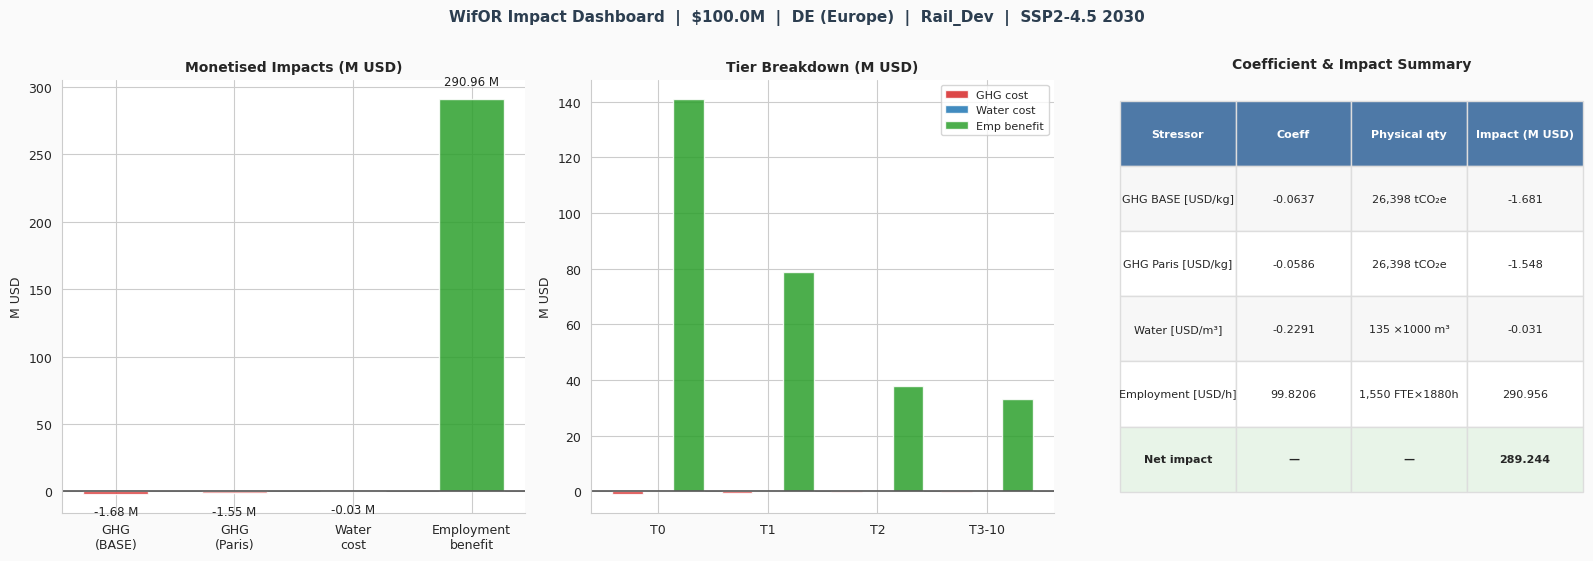

Dashboard saved -> results/wifor_dashboard_Rail_Dev_Europe_100p0M_SSP245.png


In [21]:
# ══════════════════════════════════════════════════════════════════
# SECTION 16 — WifOR NET IMPACT WATERFALL + STATIC DASHBOARD
# Waterfall: GHG BASE cost → Water cost → Employment benefit → Net
# Dashboard: 3-panel (bar / tier / coefficient table)
# ══════════════════════════════════════════════════════════════════

# ── Plotly waterfall: net impact decomposition ───────────────────────────
wf_x   = ['GHG cost\n(BASE)', 'Water cost', 'Employment\nbenefit', 'Net impact']
wf_y   = [ghg_cost_MUSD, water_cost_MUSD, emp_benefit_MUSD, net_impact_MUSD]
wf_msr = ['relative', 'relative', 'relative', 'total']

fig_wf = go.Figure(go.Waterfall(
    orientation='v', measure=wf_msr, x=wf_x, y=wf_y,
    opacity=0.88,
    connector=dict(line=dict(color='#aaa', width=1.5)),
    increasing=dict(marker=dict(color='#2ca02c')),
    decreasing=dict(marker=dict(color='#d62728')),
    totals=dict(marker=dict(
        color='#2ca02c' if net_impact_MUSD >= 0 else '#d62728')),
    text=[f'{v:.2f} M' for v in wf_y], textposition='outside',
))
fig_wf.add_annotation(
    x='GHG cost\n(BASE)', y=ghg_cost_MUSD * 0.5,
    text=f'Paris alt:<br>{ghg_paris_cost_MUSD:.2f} M',
    showarrow=True, arrowhead=2, arrowcolor='#e07070',
    font=dict(color='#e07070', size=9),
    ax=60, ay=-30,
)
fig_wf.add_hline(y=0, line_color='#555', line_width=1.2)
fig_wf.update_layout(
    title=dict(
        text=(f'<b>WifOR Net Impact Waterfall</b>'
              f'<br><span style="font-size:11px;color:#555">'
              f'{fmt_capex(CAPEX_USD)} · {COUNTRY} ({REGION}) · {SECTOR} · {sc_label}</span>'),
        x=0.01, xanchor='left', font=dict(size=14),
    ),
    height=440, margin=dict(l=20, r=20, t=110, b=20),
    paper_bgcolor='#fafafa', font=dict(family='Arial', size=11),
    yaxis_title='M USD',
    yaxis=dict(zeroline=True, zerolinewidth=1.5, zerolinecolor='#555'),
    showlegend=False,
)
display(HTML(fig_wf.to_html(full_html=False, include_plotlyjs='cdn')))

# ── Matplotlib static dashboard ──────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig_wd, axes = plt.subplots(1, 3, figsize=(16, 5.5), facecolor='#fafafa')
fig_wd.suptitle(
    (f'WifOR Impact Dashboard  |  {fmt_capex(CAPEX_USD)}  |  '
     f'{COUNTRY} ({REGION})  |  {SECTOR}  |  {sc_label}'),
    fontsize=11, fontweight='bold', y=1.01, color='#2c3e50',
)

# Panel 1 — Stressor costs/benefits
ax1 = axes[0]
p1_labels = ['GHG\n(BASE)', 'GHG\n(Paris)', 'Water\ncost', 'Employment\nbenefit']
p1_vals   = [ghg_cost_MUSD, ghg_paris_cost_MUSD, water_cost_MUSD, emp_benefit_MUSD]
p1_colors = ['#d62728', '#e07070', '#1f77b4', '#2ca02c']
bars1 = ax1.bar(p1_labels, p1_vals, color=p1_colors, alpha=0.85, edgecolor='white', width=0.55)
for b, v in zip(bars1, p1_vals):
    offset = max(abs(x) for x in p1_vals) * 0.03
    ax1.text(b.get_x() + b.get_width() / 2,
             v + offset if v >= 0 else v - offset,
             f'{v:.2f} M', ha='center',
             va='bottom' if v >= 0 else 'top',
             fontsize=8.5, color='#222')
ax1.axhline(0, color='#555', linewidth=1.2)
ax1.set_ylabel('M USD', fontsize=9)
ax1.set_title('Monetised Impacts (M USD)', fontsize=10, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)

# Panel 2 — Tier breakdown GHG cost vs Employment benefit
ax2 = axes[1]
_x2 = np.arange(4)
_w2 = 0.28
ax2.bar(_x2 - _w2, tier_ghg_MUSD,   _w2, label='GHG cost',    color='#d62728', alpha=0.85, edgecolor='white')
ax2.bar(_x2,        tier_water_MUSD, _w2, label='Water cost',  color='#1f77b4', alpha=0.85, edgecolor='white')
ax2.bar(_x2 + _w2, tier_emp_MUSD,   _w2, label='Emp benefit', color='#2ca02c', alpha=0.85, edgecolor='white')
ax2.set_xticks(_x2)
ax2.set_xticklabels(['T0', 'T1', 'T2', 'T3-10'], fontsize=9)
ax2.axhline(0, color='#555', linewidth=1.2)
ax2.set_ylabel('M USD', fontsize=9)
ax2.set_title('Tier Breakdown (M USD)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)

# Panel 3 — Coefficient & impact summary table
ax3 = axes[2]
ax3.axis('off')
tbl_data = [
    ['Stressor',           'Coeff',                'Physical qty',                    'Impact (M USD)'],
    ['GHG BASE [USD/kg]',  f'{c_ghg:.4f}',         f'{GHG_ADJ:,.0f} tCO₂e',          f'{ghg_cost_MUSD:.3f}'],
    ['GHG Paris [USD/kg]', f'{c_ghg_paris:.4f}',   f'{GHG_ADJ:,.0f} tCO₂e',          f'{ghg_paris_cost_MUSD:.3f}'],
    ['Water [USD/m³]',     f'{c_water:.4f}',       f'{WAT_ADJ:,.0f} ×1000 m³',         f'{water_cost_MUSD:.3f}'],
    ['Employment [USD/h]', f'{c_train:.4f}',        f'{EMP_ADJ:,.0f} FTE×1880h',        f'{emp_benefit_MUSD:.3f}'],
    ['Net impact',         '—',                    '—',                               f'{net_impact_MUSD:.3f}'],
]
tbl = ax3.table(cellText=tbl_data[1:], colLabels=tbl_data[0],
                cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.90])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
n_net = len(tbl_data) - 2  # 0-based row index of net row in the table body
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#ddd')
    if r == 0:   # header
        cell.set_facecolor('#4e79a7'); cell.set_text_props(color='white', fontweight='bold')
    elif r == n_net + 1:  # Net impact row
        fc = '#e8f4e8' if net_impact_MUSD >= 0 else '#fde8e8'
        cell.set_facecolor(fc); cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#f7f7f7' if r % 2 == 1 else 'white')
ax3.set_title('Coefficient & Impact Summary', fontsize=10, fontweight='bold', pad=8)

plt.tight_layout()
_slug_wd = (
    f'wifor_dashboard_{SECTOR}_{REGION}_'
    f"{fmt_capex(CAPEX_USD).replace('$','').replace('.','p')}"
    f"{'_'+SCENARIO.replace('.','').replace('-','') if SCENARIO else ''}.png"
)
RESULTS_DIR.mkdir(exist_ok=True)
fig_wd.savefig(RESULTS_DIR / _slug_wd, dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Dashboard saved -> results/{_slug_wd}')
